# MovieLens 데이터 EDA (탐색적 데이터 분석)

이 노트북에서는 Item-based 추천 시스템 구현을 위한 데이터 분석을 수행합니다.


In [47]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정 (강화 버전)
def set_korean_font_advanced():
    """시스템에 설치된 한글 폰트를 찾아서 설정 (강화 버전)"""
    
    # 1단계: matplotlib 캐시 강제 재빌드
    try:
        fm._load_fontmanager(try_read_cache=False)
    except:
        pass
    
    # 2단계: Windows 폰트 경로 직접 지정
    if platform.system() == 'Windows':
        import os
        font_dirs = [
            'C:/Windows/Fonts',
            os.path.expanduser('~') + '/AppData/Local/Microsoft/Windows/Fonts'
        ]
        
        # 폰트 파일 직접 찾기
        font_files = {
            'malgun.ttf': 'Malgun Gothic',
            'malgunbd.ttf': 'Malgun Gothic',
            'gulim.ttc': 'Gulim',
            'batang.ttc': 'Batang',
        }
        
        for font_dir in font_dirs:
            if os.path.exists(font_dir):
                for font_file, font_name in font_files.items():
                    font_path = os.path.join(font_dir, font_file)
                    if os.path.exists(font_path):
                        try:
                            fm.fontManager.addfont(font_path)
                            plt.rcParams['font.family'] = font_name
                            print(f"✅ 한글 폰트 설정 성공: {font_name} ({font_file})")
                            return font_name
                        except:
                            pass
    
    # 3단계: 폰트 이름으로 찾기 (fallback)
    korean_fonts = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 
                    'Gulim', 'Batang', 'Dotum', 'AppleGothic']
    
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in korean_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            print(f"✅ 한글 폰트 설정: {font}")
            return font
    
    # 4단계: 최후의 수단 - sans-serif 설정
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'Gulim', 'DejaVu Sans']
    plt.rcParams['font.family'] = 'sans-serif'
    print("⚠️ 대체 폰트 설정을 사용합니다.")
    return None

# 한글 폰트 설정
set_korean_font_advanced()

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 경고 메시지 무시
warnings.filterwarnings('ignore')

# 시각화 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("라이브러리 임포트 완료!")
print(f"현재 폰트 설정: {plt.rcParams['font.family']}")


Matplotlib is building the font cache; this may take a moment.


✅ 한글 폰트 설정 성공: Malgun Gothic (malgun.ttf)
라이브러리 임포트 완료!
현재 폰트 설정: ['sans-serif']


## 📝 한글 폰트 확인 및 문제 해결


🔧 한글 폰트 문제 해결

1️⃣ matplotlib 캐시 삭제 중...
   ⚠️ 캐시 삭제 실패: name 'os' is not defined

2️⃣ 폰트 매니저 재로드 중...
   ✅ 폰트 매니저 재로드 완료

3️⃣ Windows 폰트 직접 로드 중...
   ✅ 폰트 로드 성공: C:/Windows/Fonts/malgun.ttf

4️⃣ 시스템에 설치된 한글 폰트 목록:
   • Batang
   • Century Gothic
   • Copperplate Gothic Bold
   • Copperplate Gothic Light
   • Franklin Gothic Book
   • Franklin Gothic Demi
   • Franklin Gothic Demi Cond
   • Franklin Gothic Heavy
   • Franklin Gothic Medium
   • Franklin Gothic Medium Cond
   ... 외 16개

현재 설정된 폰트: ['Malgun Gothic']

5️⃣ 한글 표시 테스트:


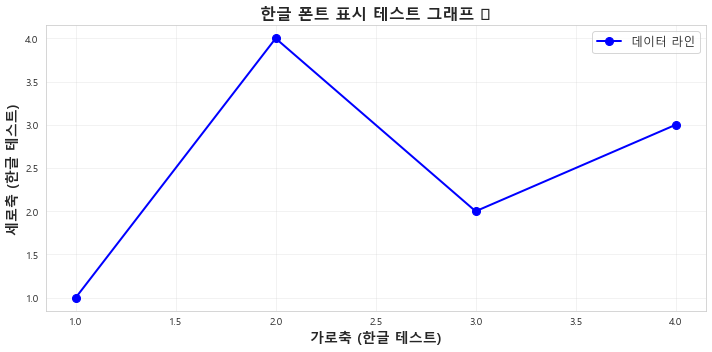


💡 다음 단계:
✅ 폰트 설정 완료! 위 그래프에서 한글이 제대로 표시되면 성공입니다.
   이제 아래 데이터 분석 셀들을 실행하세요.


In [48]:
# ⚠️ 한글이 네모(□□□)로 표시되면 이 셀을 실행하세요!

print("=" * 80)
print("🔧 한글 폰트 문제 해결")
print("=" * 80)

# 1. matplotlib 캐시 삭제
print("\n1️⃣ matplotlib 캐시 삭제 중...")
try:
    import shutil
    import matplotlib
    cache_dir = matplotlib.get_cachedir()
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print(f"   ✅ 캐시 삭제 완료: {cache_dir}")
    else:
        print(f"   ℹ️ 캐시 디렉토리 없음: {cache_dir}")
except Exception as e:
    print(f"   ⚠️ 캐시 삭제 실패: {e}")

# 2. 폰트 매니저 재로드
print("\n2️⃣ 폰트 매니저 재로드 중...")
try:
    fm._load_fontmanager(try_read_cache=False)
    print("   ✅ 폰트 매니저 재로드 완료")
except Exception as e:
    print(f"   ⚠️ 재로드 실패: {e}")

# 3. Windows 폰트 경로에서 직접 로드
print("\n3️⃣ Windows 폰트 직접 로드 중...")
import os
font_loaded = False

if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
    if os.path.exists(font_path):
        try:
            fm.fontManager.addfont(font_path)
            plt.rcParams['font.family'] = 'Malgun Gothic'
            plt.rcParams['axes.unicode_minus'] = False
            font_loaded = True
            print(f"   ✅ 폰트 로드 성공: {font_path}")
        except Exception as e:
            print(f"   ⚠️ 폰트 로드 실패: {e}")
    
    # Gulim 시도
    if not font_loaded:
        font_path = 'C:/Windows/Fonts/gulim.ttc'
        if os.path.exists(font_path):
            try:
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = 'Gulim'
                plt.rcParams['axes.unicode_minus'] = False
                font_loaded = True
                print(f"   ✅ 폰트 로드 성공: {font_path}")
            except Exception as e:
                print(f"   ⚠️ 폰트 로드 실패: {e}")

if not font_loaded:
    print("   ⚠️ 폰트 파일을 찾을 수 없습니다.")

# 4. 시스템에 설치된 한글 폰트 확인
print("\n4️⃣ 시스템에 설치된 한글 폰트 목록:")
korean_font_list = []
for font in fm.fontManager.ttflist:
    if any(keyword in font.name for keyword in ['Gothic', 'Gulim', 'Batang', 'Dotum', 'Nanum']):
        korean_font_list.append(font.name)

korean_font_list = sorted(set(korean_font_list))
if korean_font_list:
    for font in korean_font_list[:10]:  # 처음 10개만 표시
        print(f"   • {font}")
    if len(korean_font_list) > 10:
        print(f"   ... 외 {len(korean_font_list)-10}개")
else:
    print("   ⚠️ 한글 폰트를 찾지 못했습니다.")

print(f"\n현재 설정된 폰트: {plt.rcParams['font.family']}")

# 5. 테스트 그래프
print("\n5️⃣ 한글 표시 테스트:")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([1, 2, 3, 4], [1, 4, 2, 3], marker='o', linewidth=2, markersize=8, color='blue')
ax.set_xlabel('가로축 (한글 테스트)', fontsize=14, fontweight='bold')
ax.set_ylabel('세로축 (한글 테스트)', fontsize=14, fontweight='bold')
ax.set_title('한글 폰트 표시 테스트 그래프 🎨', fontsize=16, fontweight='bold')
ax.legend(['데이터 라인'], fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("💡 다음 단계:")
print("=" * 80)
if font_loaded:
    print("✅ 폰트 설정 완료! 위 그래프에서 한글이 제대로 표시되면 성공입니다.")
    print("   이제 아래 데이터 분석 셀들을 실행하세요.")
else:
    print("⚠️ 여전히 한글이 □□□로 표시되면:")
    print("   1. Jupyter 커널 재시작: Kernel → Restart")
    print("   2. 이 노트북의 첫 번째 셀(Cell 1)부터 다시 실행")
    print("   3. 그래도 안 되면 Jupyter 서버 재시작")
print("=" * 80)


## 1. 데이터 로드


In [49]:
# CSV 파일 로드
movies = pd.read_csv('data/movies.csv')
ratings = pd.read_csv('data/ratings.csv')
links = pd.read_csv('data/links.csv')
tags = pd.read_csv('data/tags.csv')

print("✅ 데이터 로드 완료!")
print(f"Movies: {movies.shape}")
print(f"Ratings: {ratings.shape}")
print(f"Links: {links.shape}")
print(f"Tags: {tags.shape}")


✅ 데이터 로드 완료!
Movies: (9742, 3)
Ratings: (100836, 4)
Links: (9742, 3)
Tags: (3683, 4)


## 2. 데이터 기본 정보 확인


In [50]:
### 2.1 Movies 데이터
print("=" * 80)
print("MOVIES 데이터셋")
print("=" * 80)
print("\n📊 처음 5개 행:")
display(movies.head())

print("\n📊 데이터 정보:")
movies.info()

print("\n📊 결측치 확인:")
print(movies.isnull().sum())

print("\n📊 기본 통계:")
print(f"총 영화 수: {movies['movieId'].nunique():,}개")
print(f"중복된 영화: {movies.duplicated().sum()}개")


MOVIES 데이터셋

📊 처음 5개 행:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



📊 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

📊 결측치 확인:
movieId    0
title      0
genres     0
dtype: int64

📊 기본 통계:
총 영화 수: 9,742개
중복된 영화: 0개


In [51]:
### 2.2 Ratings 데이터
print("=" * 80)
print("RATINGS 데이터셋")
print("=" * 80)
print("\n📊 처음 5개 행:")
display(ratings.head())

print("\n📊 데이터 정보:")
ratings.info()

print("\n📊 결측치 확인:")
print(ratings.isnull().sum())

print("\n📊 기본 통계:")
print(f"총 평점 수: {len(ratings):,}개")
print(f"유니크 사용자 수: {ratings['userId'].nunique():,}명")
print(f"유니크 영화 수: {ratings['movieId'].nunique():,}개")
print(f"평점 범위: {ratings['rating'].min()} ~ {ratings['rating'].max()}")
print(f"평균 평점: {ratings['rating'].mean():.2f}")


RATINGS 데이터셋

📊 처음 5개 행:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



📊 데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

📊 결측치 확인:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

📊 기본 통계:
총 평점 수: 100,836개
유니크 사용자 수: 610명
유니크 영화 수: 9,724개
평점 범위: 0.5 ~ 5.0
평균 평점: 3.50


In [52]:
### 2.3 Links & Tags 데이터
print("=" * 80)
print("LINKS 데이터셋")
print("=" * 80)
display(links.head())
print("\n결측치:")
print(links.isnull().sum())

print("\n" + "=" * 80)
print("TAGS 데이터셋")
print("=" * 80)
display(tags.head())
print("\n결측치:")
print(tags.isnull().sum())
print(f"\n총 태그 수: {len(tags):,}개")
print(f"유니크 태그 수: {tags['tag'].nunique():,}개")


LINKS 데이터셋


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0



결측치:
movieId    0
imdbId     0
tmdbId     8
dtype: int64

TAGS 데이터셋


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200



결측치:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

총 태그 수: 3,683개
유니크 태그 수: 1,589개


## 3. 영화 장르 분석


📊 장르별 영화 수:


,Genre,Count
6,Drama,4361
3,Comedy,3756
9,Thriller,1894
7,Action,1828
5,Romance,1596
0,Adventure,1263
8,Crime,1199
12,Sci-Fi,980
10,Horror,978
4,Fantasy,779


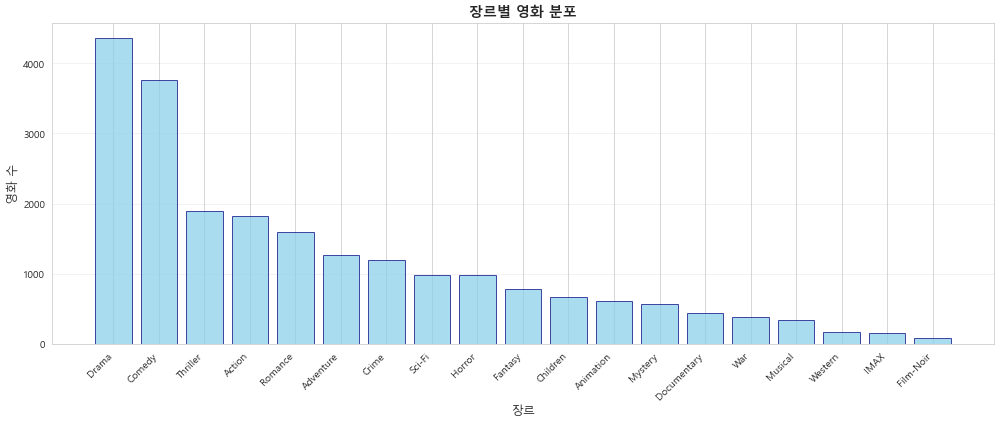


장르가 없는 영화: 34개

장르 조합 수 분포:
genres
1     2817
2     3218
3     2338
4      987
5      271
6       63
7       12
8        1
10       1
Name: count, dtype: int64


In [53]:
# 장르 데이터 파싱
all_genres = []
for genres in movies['genres']:
    if genres != '(no genres listed)':
        all_genres.extend(genres.split('|'))

# 장르별 빈도수 계산
from collections import Counter
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values('Count', ascending=False)

print("📊 장르별 영화 수:")
display(genre_df)

# 시각화
plt.figure(figsize=(14, 6))
plt.bar(genre_df['Genre'], genre_df['Count'], color='skyblue', edgecolor='navy', alpha=0.7)
plt.xlabel('장르', fontsize=12)
plt.ylabel('영화 수', fontsize=12)
plt.title('장르별 영화 분포', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 장르 조합 분석
print(f"\n장르가 없는 영화: {(movies['genres'] == '(no genres listed)').sum()}개")
movies_genres = movies[movies['genres'] != '(no genres listed)']['genres'].str.split('|')
genre_combination_counts = movies_genres.apply(len).value_counts().sort_index()
print("\n장르 조합 수 분포:")
print(genre_combination_counts)


## 4. 평점(Rating) 분석


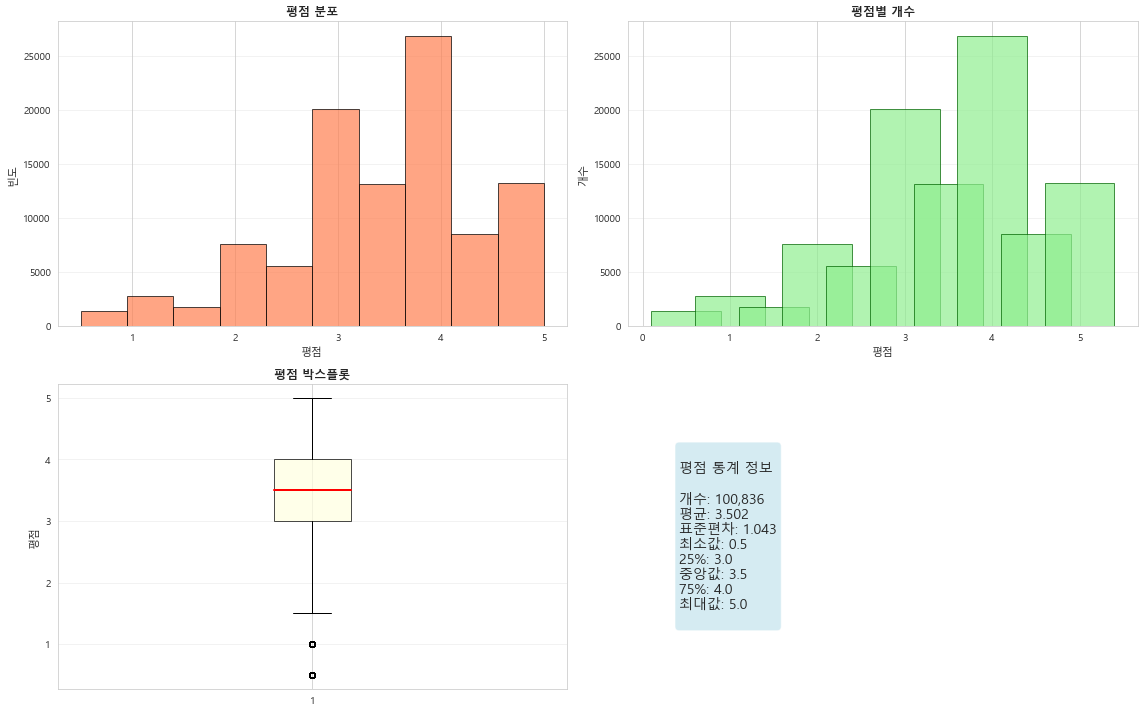

📊 평점 값별 비율:
rating
0.5     1.36
1.0     2.79
1.5     1.78
2.0     7.49
2.5     5.50
3.0    19.88
3.5    13.03
4.0    26.60
4.5     8.48
5.0    13.10
Name: proportion, dtype: float64


In [54]:
# 평점 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 평점 분포 히스토그램
axes[0, 0].hist(ratings['rating'], bins=10, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('평점', fontsize=11)
axes[0, 0].set_ylabel('빈도', fontsize=11)
axes[0, 0].set_title('평점 분포', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 평점 값별 개수
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0, 1].bar(rating_counts.index, rating_counts.values, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
axes[0, 1].set_xlabel('평점', fontsize=11)
axes[0, 1].set_ylabel('개수', fontsize=11)
axes[0, 1].set_title('평점별 개수', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. 평점 박스플롯
axes[1, 0].boxplot(ratings['rating'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightyellow', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('평점', fontsize=11)
axes[1, 0].set_title('평점 박스플롯', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. 평점 통계 정보
rating_stats = ratings['rating'].describe()
axes[1, 1].axis('off')
stats_text = f"""
평점 통계 정보

개수: {rating_stats['count']:,.0f}
평균: {rating_stats['mean']:.3f}
표준편차: {rating_stats['std']:.3f}
최소값: {rating_stats['min']:.1f}
25%: {rating_stats['25%']:.1f}
중앙값: {rating_stats['50%']:.1f}
75%: {rating_stats['75%']:.1f}
최대값: {rating_stats['max']:.1f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=14, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

print("📊 평점 값별 비율:")
print((ratings['rating'].value_counts(normalize=True).sort_index() * 100).round(2))


## 5. 사용자(User) 활동 분석


📊 사용자별 평점 개수 통계:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


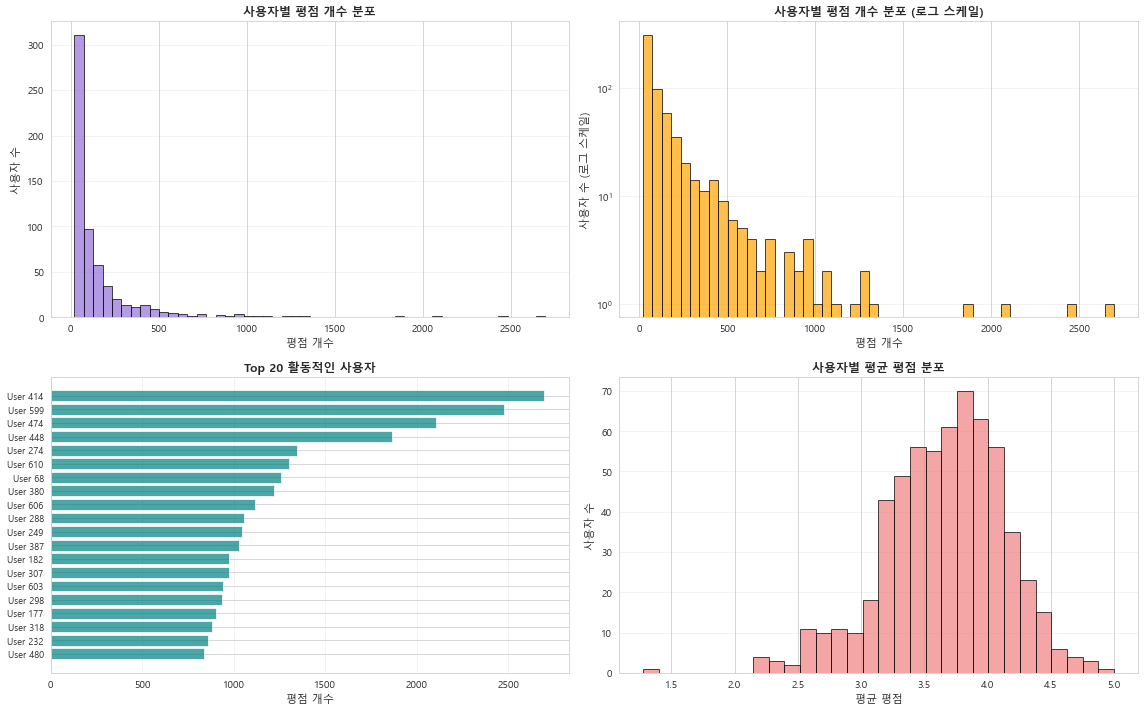


평점을 가장 많이 남긴 사용자: User 414 (2698개)
평점을 가장 적게 남긴 사용자: User 53 (20개)
사용자당 평균 평점 개수: 165.30개


In [55]:
# 사용자별 평점 개수
user_rating_counts = ratings.groupby('userId').size()

print("📊 사용자별 평점 개수 통계:")
print(user_rating_counts.describe())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 사용자별 평점 개수 분포
axes[0, 0].hist(user_rating_counts, bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('평점 개수', fontsize=11)
axes[0, 0].set_ylabel('사용자 수', fontsize=11)
axes[0, 0].set_title('사용자별 평점 개수 분포', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 로그 스케일로 본 분포
axes[0, 1].hist(user_rating_counts, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('평점 개수', fontsize=11)
axes[0, 1].set_ylabel('사용자 수 (로그 스케일)', fontsize=11)
axes[0, 1].set_title('사용자별 평점 개수 분포 (로그 스케일)', fontsize=12, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Top 20 활동적인 사용자
top_20_users = user_rating_counts.nlargest(20)
axes[1, 0].barh(range(len(top_20_users)), top_20_users.values, color='teal', alpha=0.7)
axes[1, 0].set_yticks(range(len(top_20_users)))
axes[1, 0].set_yticklabels([f'User {uid}' for uid in top_20_users.index], fontsize=9)
axes[1, 0].set_xlabel('평점 개수', fontsize=11)
axes[1, 0].set_title('Top 20 활동적인 사용자', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. 사용자별 평균 평점
user_avg_rating = ratings.groupby('userId')['rating'].mean()
axes[1, 1].hist(user_avg_rating, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('평균 평점', fontsize=11)
axes[1, 1].set_ylabel('사용자 수', fontsize=11)
axes[1, 1].set_title('사용자별 평균 평점 분포', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 추가 통계
print(f"\n평점을 가장 많이 남긴 사용자: User {user_rating_counts.idxmax()} ({user_rating_counts.max()}개)")
print(f"평점을 가장 적게 남긴 사용자: User {user_rating_counts.idxmin()} ({user_rating_counts.min()}개)")
print(f"사용자당 평균 평점 개수: {user_rating_counts.mean():.2f}개")


## 6. 영화(Movie) 인기도 분석


📊 영화별 통계:
             movieId  rating_count  rating_mean
count    9724.000000   9724.000000  9724.000000
mean    42245.024373     10.369807     3.262448
std     52191.137320     22.401005     0.869874
min         1.000000      1.000000     0.500000
25%      3245.500000      1.000000     2.800000
50%      7300.000000      3.000000     3.416667
75%     76739.250000      9.000000     3.911765
max    193609.000000    329.000000     5.000000


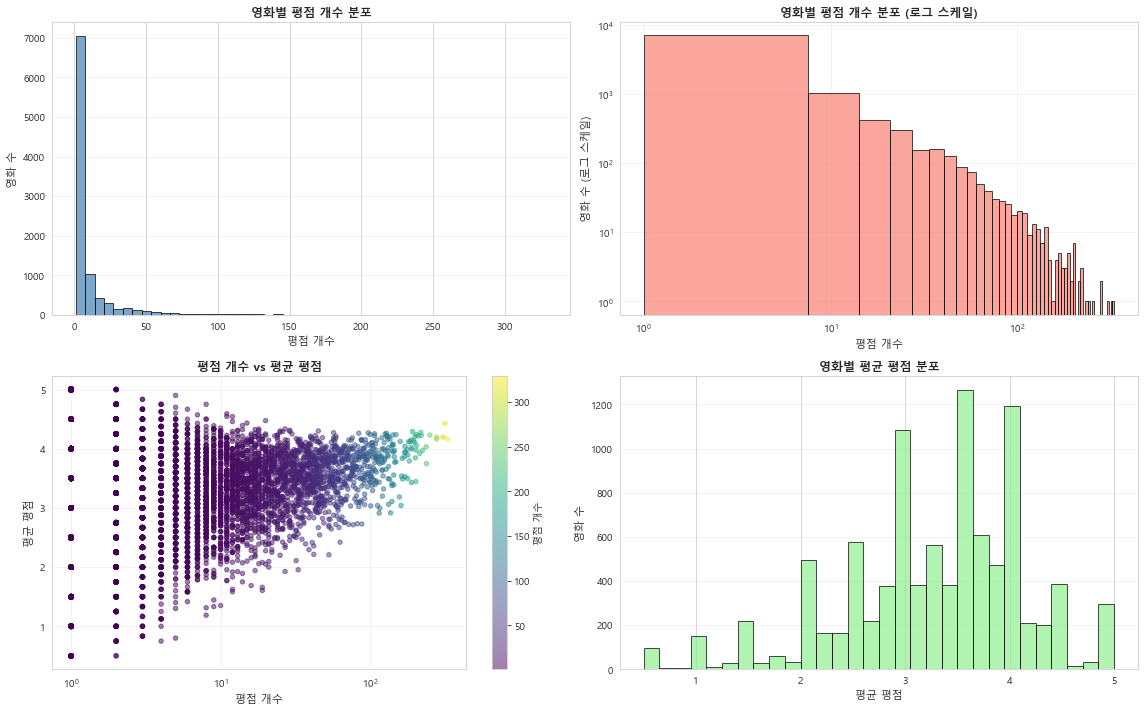


평점이 가장 많은 영화: Forrest Gump (1994)
평점 개수: 329개

영화당 평균 평점 개수: 10.37개
평점이 1개인 영화 수: 3446개


In [56]:
# 영화별 평점 개수와 평균 평점
movie_stats = ratings.groupby('movieId').agg({
    'rating': ['count', 'mean']
}).reset_index()
movie_stats.columns = ['movieId', 'rating_count', 'rating_mean']

# 영화 제목 병합
movie_stats = movie_stats.merge(movies[['movieId', 'title']], on='movieId')

print("📊 영화별 통계:")
print(movie_stats.describe())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 영화별 평점 개수 분포
axes[0, 0].hist(movie_stats['rating_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('평점 개수', fontsize=11)
axes[0, 0].set_ylabel('영화 수', fontsize=11)
axes[0, 0].set_title('영화별 평점 개수 분포', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 로그 스케일로 본 분포
axes[0, 1].hist(movie_stats['rating_count'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('평점 개수', fontsize=11)
axes[0, 1].set_ylabel('영화 수 (로그 스케일)', fontsize=11)
axes[0, 1].set_title('영화별 평점 개수 분포 (로그 스케일)', fontsize=12, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')
axes[0, 1].grid(axis='both', alpha=0.3)

# 3. 평점 개수와 평균 평점의 관계
scatter = axes[1, 0].scatter(movie_stats['rating_count'], movie_stats['rating_mean'], 
                            alpha=0.5, c=movie_stats['rating_count'], cmap='viridis', s=20)
axes[1, 0].set_xlabel('평점 개수', fontsize=11)
axes[1, 0].set_ylabel('평균 평점', fontsize=11)
axes[1, 0].set_title('평점 개수 vs 평균 평점', fontsize=12, fontweight='bold')
axes[1, 0].set_xscale('log')
axes[1, 0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='평점 개수')

# 4. 영화별 평균 평점 분포
axes[1, 1].hist(movie_stats['rating_mean'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('평균 평점', fontsize=11)
axes[1, 1].set_ylabel('영화 수', fontsize=11)
axes[1, 1].set_title('영화별 평균 평점 분포', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 통계 정보
print(f"\n평점이 가장 많은 영화: {movie_stats.loc[movie_stats['rating_count'].idxmax(), 'title']}")
print(f"평점 개수: {movie_stats['rating_count'].max()}개")
print(f"\n영화당 평균 평점 개수: {movie_stats['rating_count'].mean():.2f}개")
print(f"평점이 1개인 영화 수: {(movie_stats['rating_count'] == 1).sum()}개")


### 6.1 인기 영화 Top 20


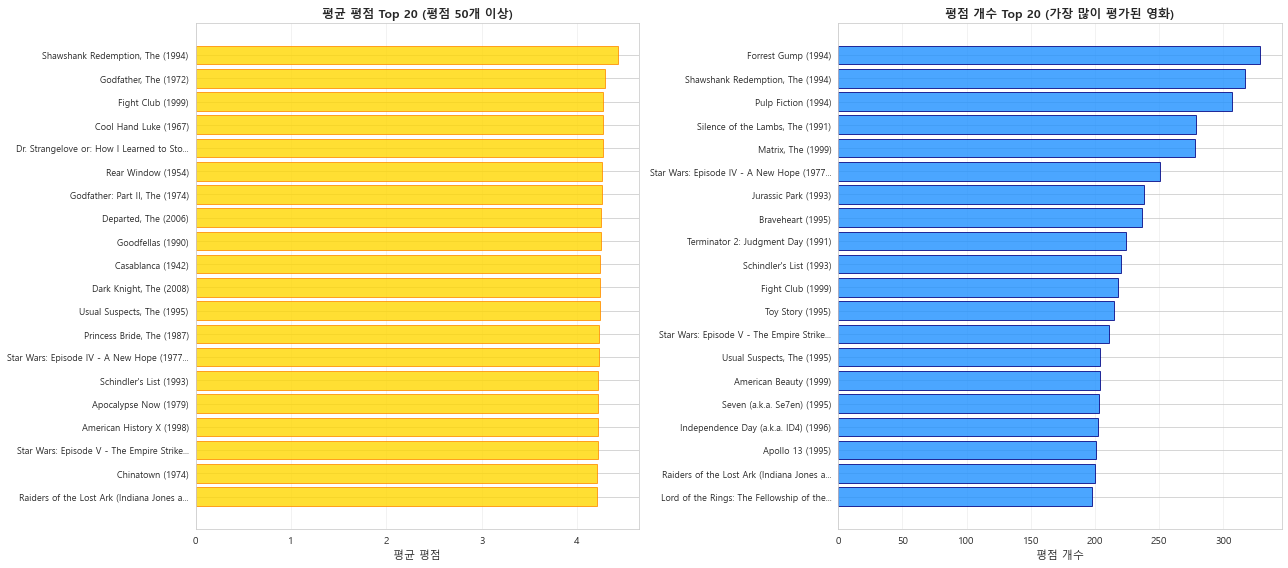

📊 평균 평점 Top 10 (평점 50개 이상):


,title,rating_mean,rating_count
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2224,Fight Club (1999),4.272936,218
974,Cool Hand Luke (1967),4.271930,57
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,Rear Window (1954),4.261905,84
921,"Godfather: Part II, The (1974)",4.259690,129
6298,"Departed, The (2006)",4.252336,107
913,Goodfellas (1990),4.250000,126
694,Casablanca (1942),4.240000,100



📊 가장 많이 평가된 영화 Top 10:


,title,rating_count,rating_mean
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


In [57]:
# 평점이 50개 이상인 영화만 필터링 (신뢰성 있는 평가)
popular_movies = movie_stats[movie_stats['rating_count'] >= 50].copy()

# 평균 평점 기준 Top 20
top_20_by_rating = popular_movies.nlargest(20, 'rating_mean')

# 평점 개수 기준 Top 20
top_20_by_count = popular_movies.nlargest(20, 'rating_count')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. 평균 평점 Top 20
axes[0].barh(range(len(top_20_by_rating)), top_20_by_rating['rating_mean'].values, 
             color='gold', edgecolor='darkorange', alpha=0.8)
axes[0].set_yticks(range(len(top_20_by_rating)))
axes[0].set_yticklabels([title[:40] + '...' if len(title) > 40 else title 
                         for title in top_20_by_rating['title'].values], fontsize=9)
axes[0].set_xlabel('평균 평점', fontsize=11)
axes[0].set_title('평균 평점 Top 20 (평점 50개 이상)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 2. 평점 개수 Top 20
axes[1].barh(range(len(top_20_by_count)), top_20_by_count['rating_count'].values,
             color='dodgerblue', edgecolor='navy', alpha=0.8)
axes[1].set_yticks(range(len(top_20_by_count)))
axes[1].set_yticklabels([title[:40] + '...' if len(title) > 40 else title 
                         for title in top_20_by_count['title'].values], fontsize=9)
axes[1].set_xlabel('평점 개수', fontsize=11)
axes[1].set_title('평점 개수 Top 20 (가장 많이 평가된 영화)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 평균 평점 Top 10 (평점 50개 이상):")
display(top_20_by_rating[['title', 'rating_mean', 'rating_count']].head(10))

print("\n📊 가장 많이 평가된 영화 Top 10:")
display(top_20_by_count[['title', 'rating_count', 'rating_mean']].head(10))


## 7. 시간대별 분석


📊 시간 범위:
가장 오래된 평점: 1996-03-29 18:36:55
가장 최근 평점: 2018-09-24 14:27:30


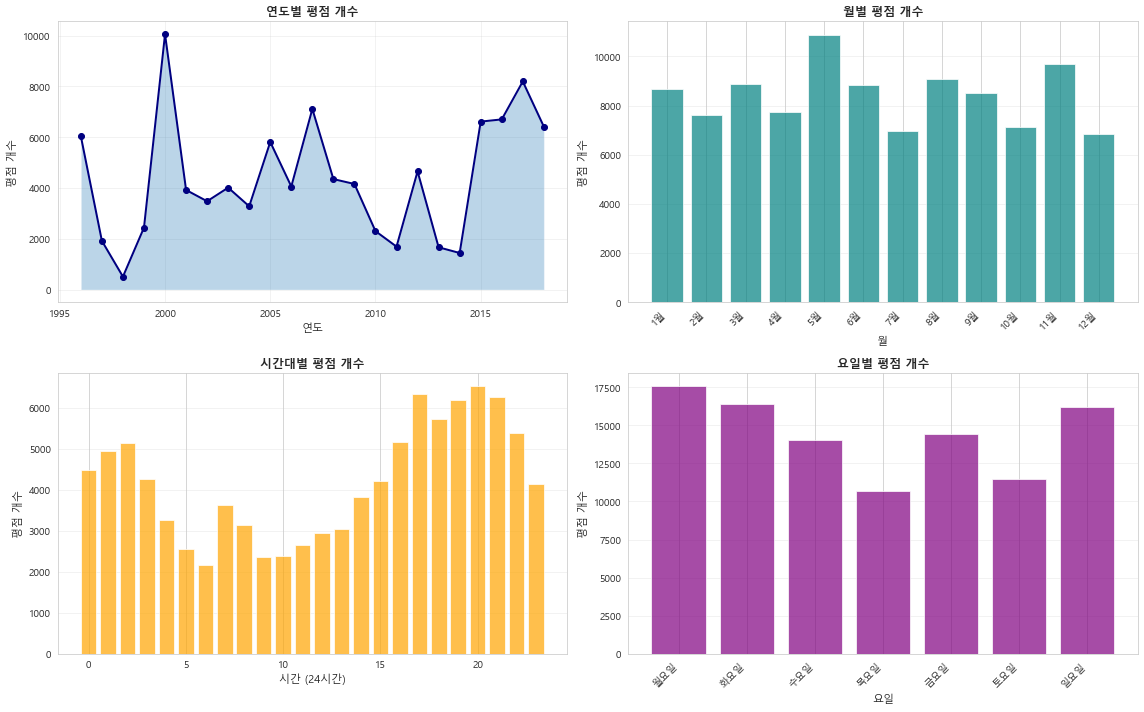

In [58]:
# timestamp를 datetime으로 변환
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['datetime'].dt.year
ratings['month'] = ratings['datetime'].dt.month
ratings['hour'] = ratings['datetime'].dt.hour
ratings['dayofweek'] = ratings['datetime'].dt.dayofweek

print("📊 시간 범위:")
print(f"가장 오래된 평점: {ratings['datetime'].min()}")
print(f"가장 최근 평점: {ratings['datetime'].max()}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 연도별 평점 개수
yearly_counts = ratings['year'].value_counts().sort_index()
axes[0, 0].plot(yearly_counts.index, yearly_counts.values, marker='o', color='navy', linewidth=2)
axes[0, 0].fill_between(yearly_counts.index, yearly_counts.values, alpha=0.3)
axes[0, 0].set_xlabel('연도', fontsize=11)
axes[0, 0].set_ylabel('평점 개수', fontsize=11)
axes[0, 0].set_title('연도별 평점 개수', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. 월별 평점 개수
monthly_counts = ratings['month'].value_counts().sort_index()
month_names = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
axes[0, 1].bar(monthly_counts.index, monthly_counts.values, color='teal', alpha=0.7)
axes[0, 1].set_xlabel('월', fontsize=11)
axes[0, 1].set_ylabel('평점 개수', fontsize=11)
axes[0, 1].set_title('월별 평점 개수', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names, rotation=45, ha='right')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. 시간대별 평점 개수
hourly_counts = ratings['hour'].value_counts().sort_index()
axes[1, 0].bar(hourly_counts.index, hourly_counts.values, color='orange', alpha=0.7)
axes[1, 0].set_xlabel('시간 (24시간)', fontsize=11)
axes[1, 0].set_ylabel('평점 개수', fontsize=11)
axes[1, 0].set_title('시간대별 평점 개수', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. 요일별 평점 개수
dow_counts = ratings['dayofweek'].value_counts().sort_index()
dow_names = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
axes[1, 1].bar(dow_counts.index, dow_counts.values, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('요일', fontsize=11)
axes[1, 1].set_ylabel('평점 개수', fontsize=11)
axes[1, 1].set_title('요일별 평점 개수', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(dow_names, rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 8. 데이터 희소성 분석 (Sparsity Analysis)


데이터 희소성 분석
총 사용자 수: 610명
총 영화 수: 9,724개
실제 평점 수: 100,836개
가능한 평점 수: 5,931,640개

희소성 (Sparsity): 98.3000%
밀도 (Density): 1.7000%


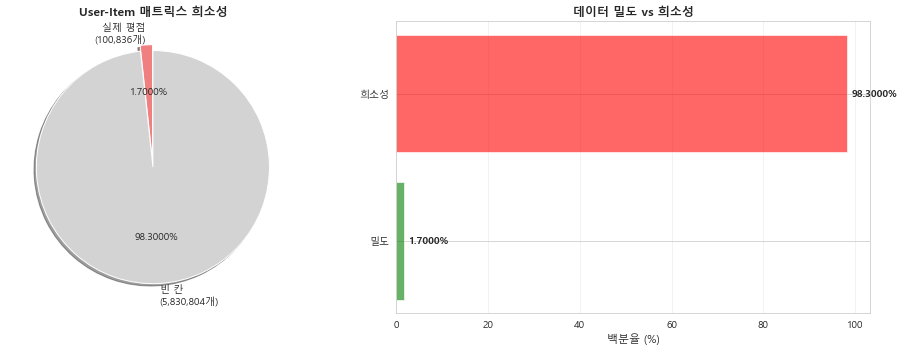


사용자당 평균 평가 영화 수: 165.30개 / 9,724개
영화당 평균 평가 수: 10.37개 / 610명


In [59]:
# 희소성 계산
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

# 가능한 모든 user-item 조합
possible_ratings = n_users * n_movies

# 희소성 (sparsity) 계산
sparsity = 1 - (n_ratings / possible_ratings)

print("=" * 80)
print("데이터 희소성 분석")
print("=" * 80)
print(f"총 사용자 수: {n_users:,}명")
print(f"총 영화 수: {n_movies:,}개")
print(f"실제 평점 수: {n_ratings:,}개")
print(f"가능한 평점 수: {possible_ratings:,}개")
print(f"\n희소성 (Sparsity): {sparsity * 100:.4f}%")
print(f"밀도 (Density): {(1 - sparsity) * 100:.4f}%")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 희소성 파이 차트
sizes = [n_ratings, possible_ratings - n_ratings]
labels = [f'실제 평점\n({n_ratings:,}개)', f'빈 칸\n({possible_ratings - n_ratings:,}개)']
colors = ['lightcoral', 'lightgray']
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.4f%%',
            shadow=True, startangle=90)
axes[0].set_title('User-Item 매트릭스 희소성', fontsize=12, fontweight='bold')

# 2. 밀도 표시
density_pct = (1 - sparsity) * 100
axes[1].barh(['밀도', '희소성'], [density_pct, sparsity * 100], 
             color=['green', 'red'], alpha=0.6)
axes[1].set_xlabel('백분율 (%)', fontsize=11)
axes[1].set_title('데이터 밀도 vs 희소성', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate([density_pct, sparsity * 100]):
    axes[1].text(v + 1, i, f'{v:.4f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 추가 통계
print(f"\n사용자당 평균 평가 영화 수: {ratings.groupby('userId').size().mean():.2f}개 / {n_movies:,}개")
print(f"영화당 평균 평가 수: {ratings.groupby('movieId').size().mean():.2f}개 / {n_users:,}명")


## 9. User-Item 매트릭스 시각화 (샘플)


9번 매트릭스 시각화로 알 수 있는 것들
1️⃣ 추천 시스템의 핵심 구조 이해
행(Row): 사용자 ID
열(Column): 영화 제목
값(Value): 각 사용자가 각 영화에 준 평점
이것이 바로 협업 필터링의 기본 데이터 구조.

2️⃣ 데이터 희소성(Sparsity) 시각적 확인
흰색/빈 칸: 해당 사용자가 그 영화를 평가하지 않음 (결측값)
색이 있는 칸: 평가된 평점 (색이 진할수록 높은 평점)
샘플 결과를 보면: 15.56% 희소성 → 약 84%가 비어있음
전체 데이터는 98%+ 희소성 (거의 모두 비어있음)

3️⃣ 사용자 평가 패턴 파악
가로줄(행)을 보면: 특정 사용자가 어떤 영화들을 평가했는지 알 수 있음
어떤 사용자는 많은 영화를 평가 → 행이 꽉 참
어떤 사용자는 적게 평가 → 행이 대부분 비어있음

4️⃣ 영화 인기도 파악
세로줄(열)을 보면: 특정 영화가 얼마나 많은 사용자에게 평가받았는지
인기 영화 → 열이 많이 채워짐
비인기 영화 → 열이 거의 비어있음

5️⃣ Item-based CF 작동 원리 이해
같은 사용자들이 평가한 영화들 = 유사한 영화
예: 영화 A와 영화 B의 열 패턴이 비슷하면 → 두 영화는 유사함
즉, 세로줄(열) 간의 유사도를 계산하는 것이 Item-based CF

Cold Start 문제 인식
평가가 거의 없는 영화(열이 거의 비어있음) → 추천하기 어려움
평가를 거의 안 한 사용자(행이 거의 비어있음) → 추천받기 어려움

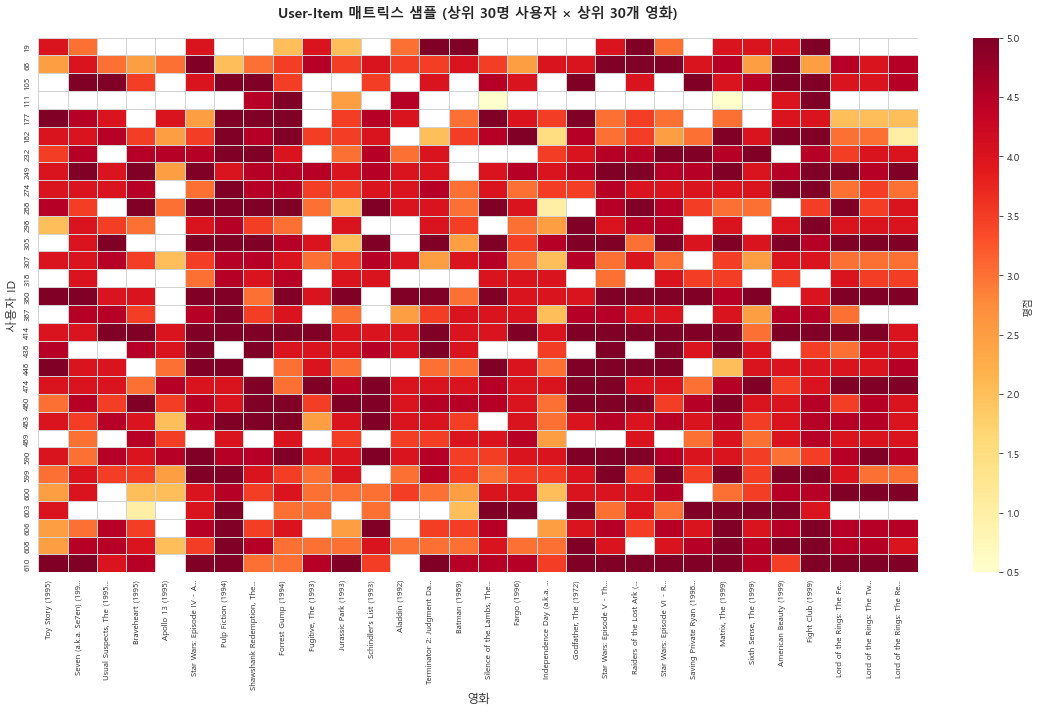

샘플 매트릭스 크기: (30, 30)
샘플 매트릭스 희소성: 15.56%


In [70]:
# 평점이 많은 사용자와 영화를 선택하여 작은 샘플 매트릭스 생성
top_users = ratings.groupby('userId').size().nlargest(30).index
top_movies_for_viz = movie_stats.nlargest(30, 'rating_count')['movieId'].values

# 샘플 데이터 필터링
sample_ratings = ratings[(ratings['userId'].isin(top_users)) & 
                         (ratings['movieId'].isin(top_movies_for_viz))]

# Pivot 테이블 생성
user_item_matrix = sample_ratings.pivot_table(index='userId', 
                                               columns='movieId', 
                                               values='rating')

# 영화 제목으로 컬럼명 변경 (일부만)
movie_id_to_title = dict(zip(movies['movieId'], movies['title']))
user_item_matrix.columns = [movie_id_to_title.get(mid, mid) for mid in user_item_matrix.columns]

# 제목을 30자로 제한
user_item_matrix.columns = [title[:25] + '...' if len(str(title)) > 25 else title 
                             for title in user_item_matrix.columns]

# 히트맵 시각화
plt.figure(figsize=(16, 10))
sns.heatmap(user_item_matrix, cmap='YlOrRd', cbar_kws={'label': '평점'}, 
            linewidths=0.5, linecolor='lightgray', 
            xticklabels=True, yticklabels=True)
plt.title('User-Item 매트릭스 샘플 (상위 30명 사용자 × 상위 30개 영화)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('영화', fontsize=12)
plt.ylabel('사용자 ID', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print(f"샘플 매트릭스 크기: {user_item_matrix.shape}")
print(f"샘플 매트릭스 희소성: {user_item_matrix.isna().sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]) * 100:.2f}%")


## 10. 태그(Tag) 분석


📊 태그 데이터 통계:
총 태그 수: 3,683개
유니크 태그 수: 1,589개
태그가 달린 영화 수: 1,572개
태그를 단 사용자 수: 58명


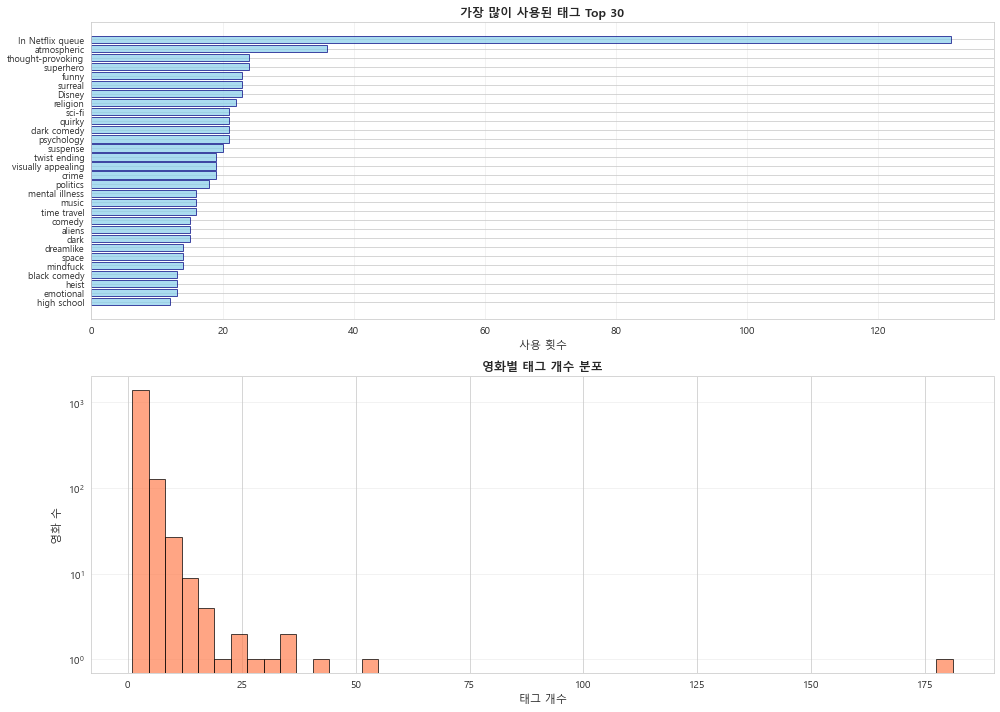


📊 태그가 가장 많은 영화 Top 10:


,title,tag_count
0,Pulp Fiction (1994),181
1,Fight Club (1999),54
2,2001: A Space Odyssey (1968),41
3,Léon: The Professional (a.k.a. The Professiona...,35
4,Eternal Sunshine of the Spotless Mind (2004),34
5,"Big Lebowski, The (1998)",32
6,Donnie Darko (2001),29
7,Star Wars: Episode IV - A New Hope (1977),26
8,Inception (2010),26
9,Suicide Squad (2016),19


In [61]:
# 태그 데이터 분석
print("📊 태그 데이터 통계:")
print(f"총 태그 수: {len(tags):,}개")
print(f"유니크 태그 수: {tags['tag'].nunique():,}개")
print(f"태그가 달린 영화 수: {tags['movieId'].nunique():,}개")
print(f"태그를 단 사용자 수: {tags['userId'].nunique():,}명")

# 가장 많이 사용된 태그 Top 30
tag_counts = tags['tag'].value_counts().head(30)

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Top 30 태그
axes[0].barh(range(len(tag_counts)), tag_counts.values, color='skyblue', edgecolor='navy', alpha=0.7)
axes[0].set_yticks(range(len(tag_counts)))
axes[0].set_yticklabels(tag_counts.index, fontsize=9)
axes[0].set_xlabel('사용 횟수', fontsize=11)
axes[0].set_title('가장 많이 사용된 태그 Top 30', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 2. 영화별 태그 개수 분포
movie_tag_counts = tags.groupby('movieId').size()
axes[1].hist(movie_tag_counts, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('태그 개수', fontsize=11)
axes[1].set_ylabel('영화 수', fontsize=11)
axes[1].set_title('영화별 태그 개수 분포', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 태그가 가장 많은 영화
most_tagged_movies = tags.groupby('movieId').size().nlargest(10)
most_tagged_movies_df = pd.DataFrame({
    'movieId': most_tagged_movies.index,
    'tag_count': most_tagged_movies.values
})
most_tagged_movies_df = most_tagged_movies_df.merge(movies[['movieId', 'title']], on='movieId')

print("\n📊 태그가 가장 많은 영화 Top 10:")
display(most_tagged_movies_df[['title', 'tag_count']])


## 11. 삭제


🎬 리메이크 영화 분석

총 리메이크 의심 영화: 255개
총 리메이크 버전 수: 536개

📊 리메이크가 가장 많은 영화 Top 10:

'Hamlet' - 5개 버전
  • 1948년 - 평점: 3.50 (2개)
  • 1964년 - 평점: 4.00 (1개)
  • 1990년 - 평점: 3.80 (5개)
  • 1996년 - 평점: 4.00 (16개)
  • 2000년 - 평점: 3.00 (3개)

'Three Musketeers, The' - 4개 버전
  • 1948년 - 평점: 3.50 (1개)
  • 1973년 - 평점: 4.00 (3개)
  • 1993년 - 평점: 3.26 (61개)
  • 2011년 - 평점: 3.17 (3개)

'Jane Eyre' - 4개 버전
  • 1944년 - 평점: 5.00 (1개)
  • 1970년 - 평점: 3.50 (1개)
  • 1996년 - 평점: 3.19 (8개)
  • 2011년 - 평점: 3.00 (1개)

'Misérables, Les' - 4개 버전
  • 1995년 - 평점: 3.46 (13개)
  • 1998년 - 평점: 3.75 (10개)
  • 2000년 - 평점: 2.25 (2개)
  • 2012년 - 평점: 3.50 (7개)

'Christmas Carol, A' - 4개 버전
  • 1938년 - 평점: 3.38 (4개)
  • 1977년 - 평점: 0.50 (1개)
  • 1999년 - 평점: 3.00 (1개)
  • 2009년 - 평점: 3.00 (2개)

'King Solomon's Mines' - 3개 버전
  • 1937년 - 평점: 2.50 (1개)
  • 1950년 - 평점: 3.00 (1개)
  • 1985년 - 평점: 2.50 (1개)

'Mummy, The' - 3개 버전
  • 1932년 - 평점: 3.33 (3개)
  • 1959년 - 평점: 3.33 (3개)
  • 1999년 - 평점: 3.12 (87개)

'Project X' - 3개 버전
  • 1968년 - 

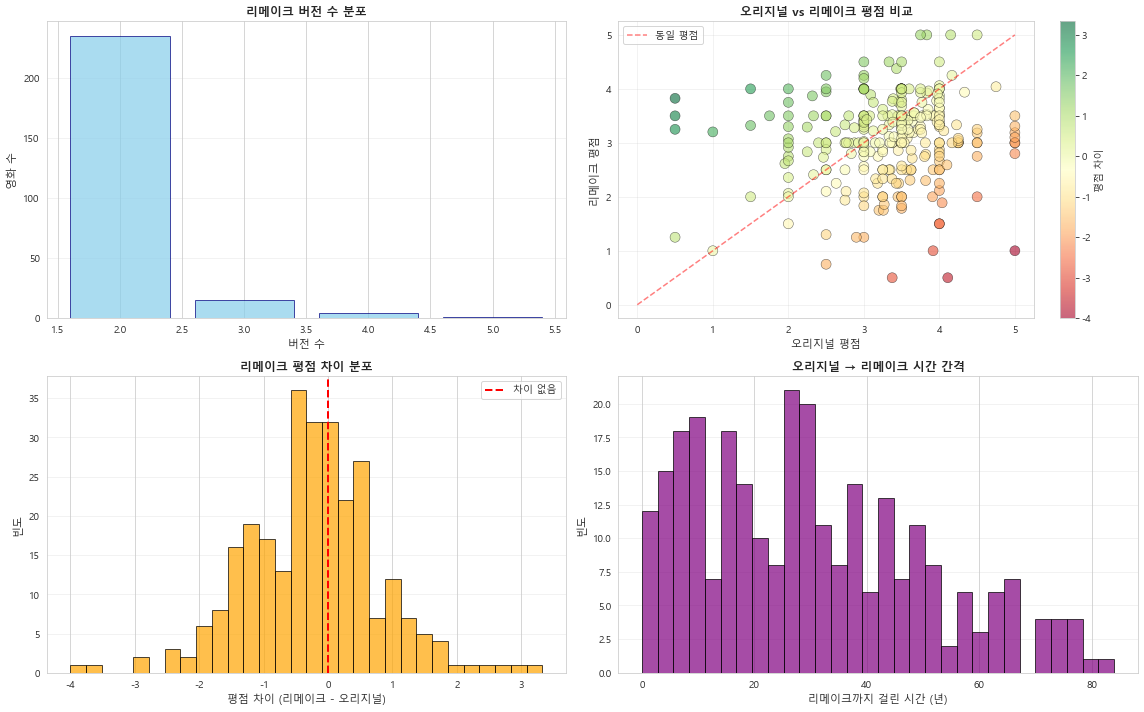


📈 리메이크 통계 분석

평점 비교 (오리지널 vs 리메이크):
  • 리메이크가 더 높은 경우: 103개 (37.1%)
  • 오리지널이 더 높은 경우: 163개 (58.6%)
  • 평균 평점 차이: -0.249
  • 평균 리메이크 간격: 29.9년

🏆 가장 성공한 리메이크 Top 5 (평점 상승):
  • Iron Man
    오리지널 (1931): 0.50 → 리메이크 (2008): 3.82 (+3.32)
  • Collector, The
    오리지널 (1965): 0.50 → 리메이크 (2009): 3.50 (+3.00)
  • Derailed
    오리지널 (2002): 0.50 → 리메이크 (2005): 3.25 (+2.75)
  • Double, The
    오리지널 (2011): 1.50 → 리메이크 (2013): 4.00 (+2.50)
  • Ring, The
    오리지널 (1927): 1.00 → 리메이크 (2002): 3.20 (+2.20)

💔 가장 실패한 리메이크 Top 5 (평점 하락):
  • Oscar
    오리지널 (1967): 5.00 → 리메이크 (1991): 1.00 (-4.00)
  • Unforgiven
    오리지널 (1992): 4.11 → 리메이크 (2013): 0.50 (-3.61)
  • Wicker Man, The
    오리지널 (1973): 3.92 → 리메이크 (2006): 1.00 (-2.92)
  • Christmas Carol, A
    오리지널 (1938): 3.38 → 리메이크 (1977): 0.50 (-2.88)
  • Zulu
    오리지널 (1964): 4.00 → 리메이크 (2013): 1.50 (-2.50)

💡 인사이트:
  • 평균적으로 오리지널이 리메이크보다 0.249점 더 높습니다.
  • 리메이크는 오리지널의 인지도를 활용할 수 있는 전략입니다.
  • 추천 시스템에서 리메이크 정보를 활용하면 더 나은 추천 가능합니다.


In [73]:
# 리메이크 영화 분석
# 제목에서 연도를 제거하고 동일한 제목의 영화가 여러 개 있는지 확인

def extract_title_without_year(title):
    """영화 제목에서 연도 부분을 제거"""
    match = re.search(r'^(.*?)\s*\(\d{4}\)', title)
    if match:
        return match.group(1).strip()
    return title.strip()

# 연도 없는 제목 추출
movies['title_clean'] = movies['title'].apply(extract_title_without_year)

# 같은 제목의 영화가 여러 개 있는지 확인 (리메이크 후보)
title_counts = movies['title_clean'].value_counts()
remakes = title_counts[title_counts > 1]

print("=" * 80)
print("🎬 리메이크 영화 분석")
print("=" * 80)
print(f"\n총 리메이크 의심 영화: {len(remakes)}개")
print(f"총 리메이크 버전 수: {remakes.sum()}개")

# 리메이크 영화 상세 정보
remake_movies = movies[movies['title_clean'].isin(remakes.index)].copy()
remake_movies = remake_movies.sort_values(['title_clean', 'release_year'])

# 평점 정보와 병합
remake_with_ratings = remake_movies.merge(movie_stats[['movieId', 'rating_count', 'rating_mean']], 
                                           on='movieId', how='left')

print("\n📊 리메이크가 가장 많은 영화 Top 10:")
top_remakes = remakes.nlargest(10)
for title, count in top_remakes.items():
    versions = remake_with_ratings[remake_with_ratings['title_clean'] == title][['title', 'release_year', 'rating_mean', 'rating_count']]
    print(f"\n'{title}' - {count}개 버전")
    for _, row in versions.iterrows():
        rating_info = f"평점: {row['rating_mean']:.2f} ({int(row['rating_count'])}개)" if pd.notna(row['rating_mean']) else "평점 없음"
        print(f"  • {int(row['release_year'])}년 - {rating_info}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 리메이크 빈도 분포
remake_freq = remakes.value_counts().sort_index()
axes[0, 0].bar(remake_freq.index, remake_freq.values, color='skyblue', edgecolor='navy', alpha=0.7)
axes[0, 0].set_xlabel('버전 수', fontsize=11)
axes[0, 0].set_ylabel('영화 수', fontsize=11)
axes[0, 0].set_title('리메이크 버전 수 분포', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 오리지널 vs 리메이크 평점 비교
original_vs_remake = []
for title in remakes.index:
    versions = remake_with_ratings[remake_with_ratings['title_clean'] == title].copy()
    versions = versions.dropna(subset=['rating_mean', 'release_year'])
    if len(versions) >= 2:
        versions = versions.sort_values('release_year')
        original = versions.iloc[0]
        for _, remake in versions.iloc[1:].iterrows():
            original_vs_remake.append({
                'title': title,
                'original_rating': original['rating_mean'],
                'remake_rating': remake['rating_mean'],
                'original_year': original['release_year'],
                'remake_year': remake['release_year'],
                'rating_diff': remake['rating_mean'] - original['rating_mean']
            })

if original_vs_remake:
    comparison_df = pd.DataFrame(original_vs_remake)
    
    # 산점도
    scatter = axes[0, 1].scatter(comparison_df['original_rating'], 
                                  comparison_df['remake_rating'],
                                  c=comparison_df['rating_diff'], 
                                  cmap='RdYlGn', s=100, alpha=0.6,
                                  edgecolor='black', linewidth=0.5)
    axes[0, 1].plot([0, 5], [0, 5], 'r--', alpha=0.5, label='동일 평점')
    axes[0, 1].set_xlabel('오리지널 평점', fontsize=11)
    axes[0, 1].set_ylabel('리메이크 평점', fontsize=11)
    axes[0, 1].set_title('오리지널 vs 리메이크 평점 비교', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 1], label='평점 차이')
    
    # 3. 평점 차이 분포
    axes[1, 0].hist(comparison_df['rating_diff'], bins=30, 
                    color='orange', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='차이 없음')
    axes[1, 0].set_xlabel('평점 차이 (리메이크 - 오리지널)', fontsize=11)
    axes[1, 0].set_ylabel('빈도', fontsize=11)
    axes[1, 0].set_title('리메이크 평점 차이 분포', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. 연도 차이 분포
    comparison_df['year_gap'] = comparison_df['remake_year'] - comparison_df['original_year']
    axes[1, 1].hist(comparison_df['year_gap'], bins=30, 
                    color='purple', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('리메이크까지 걸린 시간 (년)', fontsize=11)
    axes[1, 1].set_ylabel('빈도', fontsize=11)
    axes[1, 1].set_title('오리지널 → 리메이크 시간 간격', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 통계 분석
    print("\n" + "=" * 80)
    print("📈 리메이크 통계 분석")
    print("=" * 80)
    print(f"\n평점 비교 (오리지널 vs 리메이크):")
    print(f"  • 리메이크가 더 높은 경우: {(comparison_df['rating_diff'] > 0).sum()}개 ({(comparison_df['rating_diff'] > 0).sum() / len(comparison_df) * 100:.1f}%)")
    print(f"  • 오리지널이 더 높은 경우: {(comparison_df['rating_diff'] < 0).sum()}개 ({(comparison_df['rating_diff'] < 0).sum() / len(comparison_df) * 100:.1f}%)")
    print(f"  • 평균 평점 차이: {comparison_df['rating_diff'].mean():.3f}")
    print(f"  • 평균 리메이크 간격: {comparison_df['year_gap'].mean():.1f}년")
    
    # 가장 성공한 리메이크
    print("\n🏆 가장 성공한 리메이크 Top 5 (평점 상승):")
    best_remakes = comparison_df.nlargest(5, 'rating_diff')
    for _, row in best_remakes.iterrows():
        print(f"  • {row['title']}")
        print(f"    오리지널 ({int(row['original_year'])}): {row['original_rating']:.2f} → 리메이크 ({int(row['remake_year'])}): {row['remake_rating']:.2f} (+{row['rating_diff']:.2f})")
    
    # 가장 실패한 리메이크
    print("\n💔 가장 실패한 리메이크 Top 5 (평점 하락):")
    worst_remakes = comparison_df.nsmallest(5, 'rating_diff')
    for _, row in worst_remakes.iterrows():
        print(f"  • {row['title']}")
        print(f"    오리지널 ({int(row['original_year'])}): {row['original_rating']:.2f} → 리메이크 ({int(row['remake_year'])}): {row['remake_rating']:.2f} ({row['rating_diff']:.2f})")
else:
    print("\n⚠️ 평점이 있는 리메이크 영화 쌍이 부족합니다.")
    axes[0, 1].text(0.5, 0.5, '데이터 부족', ha='center', va='center', fontsize=14)
    axes[1, 0].text(0.5, 0.5, '데이터 부족', ha='center', va='center', fontsize=14)
    axes[1, 1].text(0.5, 0.5, '데이터 부족', ha='center', va='center', fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n💡 인사이트:")
if original_vs_remake:
    avg_diff = comparison_df['rating_diff'].mean()
    if avg_diff > 0:
        print(f"  • 평균적으로 리메이크가 오리지널보다 {avg_diff:.3f}점 더 높습니다.")
    else:
        print(f"  • 평균적으로 오리지널이 리메이크보다 {abs(avg_diff):.3f}점 더 높습니다.")
print("  • 리메이크는 오리지널의 인지도를 활용할 수 있는 전략입니다.")
print("  • 추천 시스템에서 리메이크 정보를 활용하면 더 나은 추천 가능합니다.")

## 12. 영화 개봉 연도 분석


📊 개봉 연도 정보:
연도 정보가 있는 영화: 9,729개 / 9,742개
가장 오래된 영화: 1902년
가장 최신 영화: 2018년


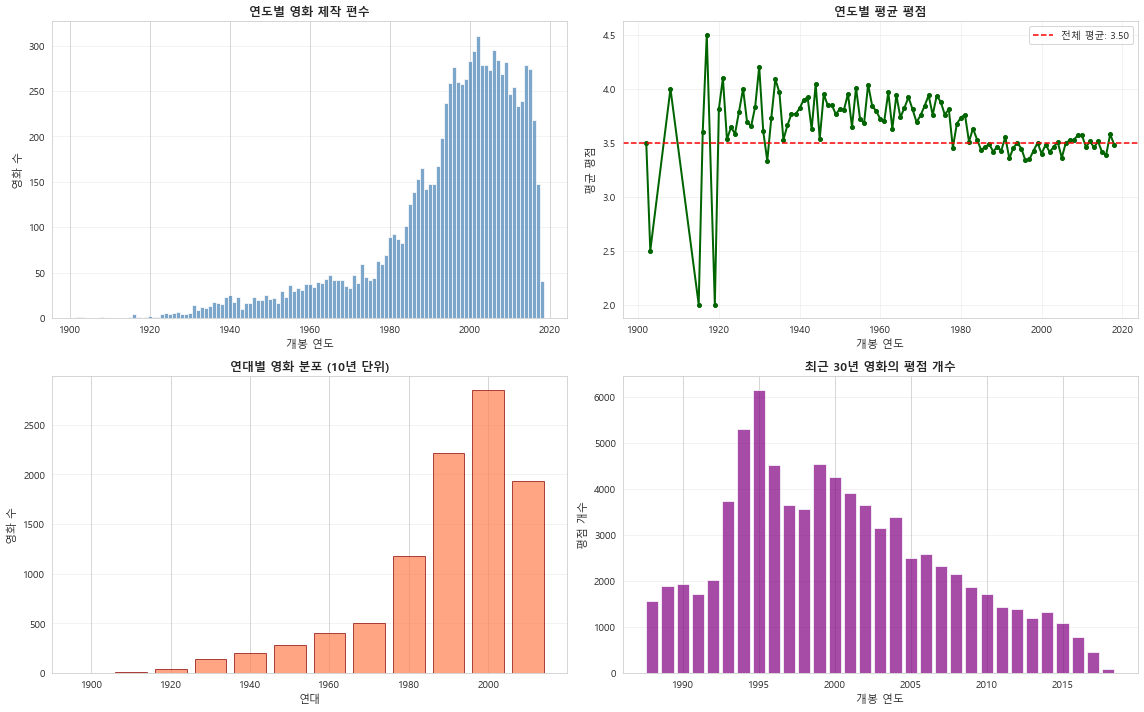


📊 연대별 통계:


,영화 수,시작년도,종료년도
decade,,,
1920.0,37,1920.0,1929.0
1930.0,136,1930.0,1939.0
1940.0,197,1940.0,1949.0
1950.0,279,1950.0,1959.0
1960.0,401,1960.0,1969.0
1970.0,500,1970.0,1979.0
1980.0,1177,1980.0,1989.0
1990.0,2212,1990.0,1999.0
2000.0,2849,2000.0,2009.0


In [63]:
# 영화 제목에서 연도 추출
import re

def extract_year(title):
    """영화 제목에서 연도 추출"""
    match = re.search(r'\((\d{4})\)', title)
    if match:
        return int(match.group(1))
    return None

movies['release_year'] = movies['title'].apply(extract_year)

# 연도가 추출된 영화만 필터링
movies_with_year = movies[movies['release_year'].notna()].copy()

print(f"📊 개봉 연도 정보:")
print(f"연도 정보가 있는 영화: {len(movies_with_year):,}개 / {len(movies):,}개")
print(f"가장 오래된 영화: {movies_with_year['release_year'].min():.0f}년")
print(f"가장 최신 영화: {movies_with_year['release_year'].max():.0f}년")

# 평점 데이터와 병합
ratings_with_year = ratings.merge(movies_with_year[['movieId', 'release_year']], on='movieId', how='left')

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 연도별 영화 제작 편수
year_counts = movies_with_year['release_year'].value_counts().sort_index()
axes[0, 0].bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.7, width=1)
axes[0, 0].set_xlabel('개봉 연도', fontsize=11)
axes[0, 0].set_ylabel('영화 수', fontsize=11)
axes[0, 0].set_title('연도별 영화 제작 편수', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 연도별 평균 평점
yearly_avg_rating = ratings_with_year.groupby('release_year')['rating'].mean()
axes[0, 1].plot(yearly_avg_rating.index, yearly_avg_rating.values, 
                marker='o', color='darkgreen', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('개봉 연도', fontsize=11)
axes[0, 1].set_ylabel('평균 평점', fontsize=11)
axes[0, 1].set_title('연도별 평균 평점', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].axhline(y=ratings['rating'].mean(), color='red', linestyle='--', 
                    label=f'전체 평균: {ratings["rating"].mean():.2f}')
axes[0, 1].legend()

# 3. 연대별 영화 분포 (10년 단위)
movies_with_year['decade'] = (movies_with_year['release_year'] // 10) * 10
decade_counts = movies_with_year['decade'].value_counts().sort_index()
axes[1, 0].bar(decade_counts.index, decade_counts.values, 
               color='coral', edgecolor='darkred', alpha=0.7, width=8)
axes[1, 0].set_xlabel('연대', fontsize=11)
axes[1, 0].set_ylabel('영화 수', fontsize=11)
axes[1, 0].set_title('연대별 영화 분포 (10년 단위)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(decade_counts.index[::2])
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. 연도별 평점 개수 (최근 30년)
recent_year = movies_with_year['release_year'].max() - 30
recent_ratings = ratings_with_year[ratings_with_year['release_year'] >= recent_year]
yearly_rating_counts = recent_ratings.groupby('release_year').size()
axes[1, 1].bar(yearly_rating_counts.index, yearly_rating_counts.values, 
               color='purple', alpha=0.7)
axes[1, 1].set_xlabel('개봉 연도', fontsize=11)
axes[1, 1].set_ylabel('평점 개수', fontsize=11)
axes[1, 1].set_title(f'최근 30년 영화의 평점 개수', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 연대별 통계
print("\n📊 연대별 통계:")
decade_stats = movies_with_year.groupby('decade').agg({
    'movieId': 'count',
    'release_year': ['min', 'max']
}).round(0)
decade_stats.columns = ['영화 수', '시작년도', '종료년도']
display(decade_stats.tail(10))


## 13. 장르별 평균 평점 및 인기도 분석


📊 장르별 평점 통계:


,평균평점,평점개수,표준편차,중앙값
genre,,,,
Film-Noir,3.920,870,0.887,4.0
War,3.808,4859,0.979,4.0
Documentary,3.798,1219,0.820,4.0
Crime,3.658,16681,0.995,4.0
Drama,3.656,41928,0.979,4.0
Mystery,3.632,7674,1.006,4.0
Animation,3.630,6988,0.970,4.0
IMAX,3.618,4145,0.988,4.0
Western,3.584,1930,1.012,4.0


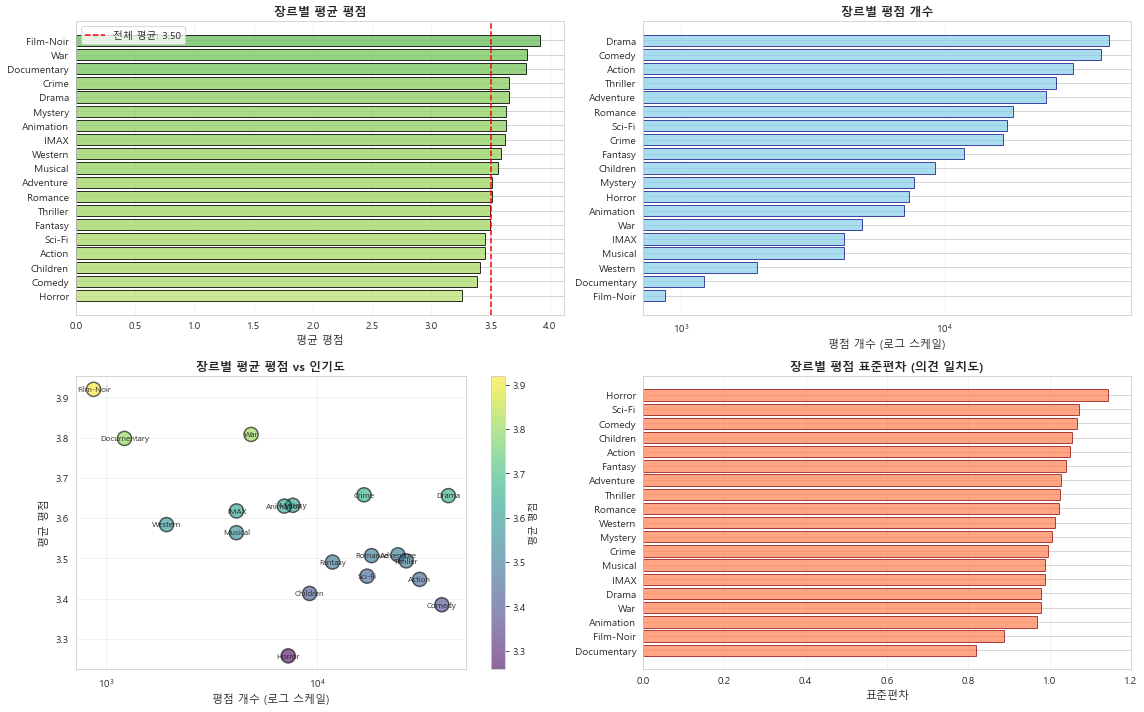


💡 인사이트:
- 평균 평점이 가장 높은 장르: Film-Noir (3.920)
- 평균 평점이 가장 낮은 장르: Horror (3.258)
- 가장 많이 평가된 장르: Drama (41,928개)
- 표준편차가 가장 작은 장르 (의견 일치): Documentary (0.820)


In [64]:
# 장르별 평점 분석을 위한 데이터 준비
genre_ratings = []

for _, row in movies.iterrows():
    if row['genres'] != '(no genres listed)':
        genres = row['genres'].split('|')
        movie_id = row['movieId']
        
        # 해당 영화의 평점 가져오기
        movie_ratings = ratings[ratings['movieId'] == movie_id]['rating']
        
        if len(movie_ratings) > 0:
            for genre in genres:
                for rating in movie_ratings:
                    genre_ratings.append({'genre': genre, 'rating': rating})

genre_ratings_df = pd.DataFrame(genre_ratings)

# 장르별 통계
genre_stats = genre_ratings_df.groupby('genre')['rating'].agg([
    ('평균평점', 'mean'),
    ('평점개수', 'count'),
    ('표준편차', 'std'),
    ('중앙값', 'median')
]).round(3).sort_values('평균평점', ascending=False)

print("📊 장르별 평점 통계:")
display(genre_stats)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 장르별 평균 평점
genre_stats_sorted = genre_stats.sort_values('평균평점', ascending=True)
colors = plt.cm.RdYlGn(genre_stats_sorted['평균평점'] / 5.0)
axes[0, 0].barh(range(len(genre_stats_sorted)), genre_stats_sorted['평균평점'], 
                color=colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_yticks(range(len(genre_stats_sorted)))
axes[0, 0].set_yticklabels(genre_stats_sorted.index, fontsize=10)
axes[0, 0].set_xlabel('평균 평점', fontsize=11)
axes[0, 0].set_title('장르별 평균 평점', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=ratings['rating'].mean(), color='red', linestyle='--', 
                    label=f'전체 평균: {ratings["rating"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. 장르별 평점 개수 (로그 스케일)
genre_stats_by_count = genre_stats.sort_values('평점개수', ascending=True)
axes[0, 1].barh(range(len(genre_stats_by_count)), genre_stats_by_count['평점개수'],
                color='skyblue', edgecolor='navy', alpha=0.7)
axes[0, 1].set_yticks(range(len(genre_stats_by_count)))
axes[0, 1].set_yticklabels(genre_stats_by_count.index, fontsize=10)
axes[0, 1].set_xlabel('평점 개수 (로그 스케일)', fontsize=11)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('장르별 평점 개수', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. 평균 평점 vs 평점 개수 산점도
scatter = axes[1, 0].scatter(genre_stats['평점개수'], genre_stats['평균평점'],
                             s=200, alpha=0.6, c=genre_stats['평균평점'], 
                             cmap='viridis', edgecolor='black', linewidth=1.5)
for idx, row in genre_stats.iterrows():
    axes[1, 0].annotate(idx, (row['평점개수'], row['평균평점']),
                        fontsize=8, ha='center', va='center')
axes[1, 0].set_xlabel('평점 개수 (로그 스케일)', fontsize=11)
axes[1, 0].set_ylabel('평균 평점', fontsize=11)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('장르별 평균 평점 vs 인기도', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='평균 평점')

# 4. 장르별 평점 분산 (표준편차)
genre_stats_by_std = genre_stats.sort_values('표준편차', ascending=True)
axes[1, 1].barh(range(len(genre_stats_by_std)), genre_stats_by_std['표준편차'],
                color='coral', edgecolor='darkred', alpha=0.7)
axes[1, 1].set_yticks(range(len(genre_stats_by_std)))
axes[1, 1].set_yticklabels(genre_stats_by_std.index, fontsize=10)
axes[1, 1].set_xlabel('표준편차', fontsize=11)
axes[1, 1].set_title('장르별 평점 표준편차 (의견 일치도)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 인사이트:")
print(f"- 평균 평점이 가장 높은 장르: {genre_stats.iloc[0].name} ({genre_stats.iloc[0]['평균평점']:.3f})")
print(f"- 평균 평점이 가장 낮은 장르: {genre_stats.iloc[-1].name} ({genre_stats.iloc[-1]['평균평점']:.3f})")
print(f"- 가장 많이 평가된 장르: {genre_stats['평점개수'].idxmax()} ({genre_stats['평점개수'].max():,}개)")
print(f"- 표준편차가 가장 작은 장르 (의견 일치): {genre_stats['표준편차'].idxmin()} ({genre_stats.loc[genre_stats['표준편차'].idxmin(), '표준편차']:.3f})")


## 14. 영화별 평점 분산 분석 (논란의 영화 찾기)


📊 평점이 30개 이상인 영화: 882개
평균 표준편차: 0.916


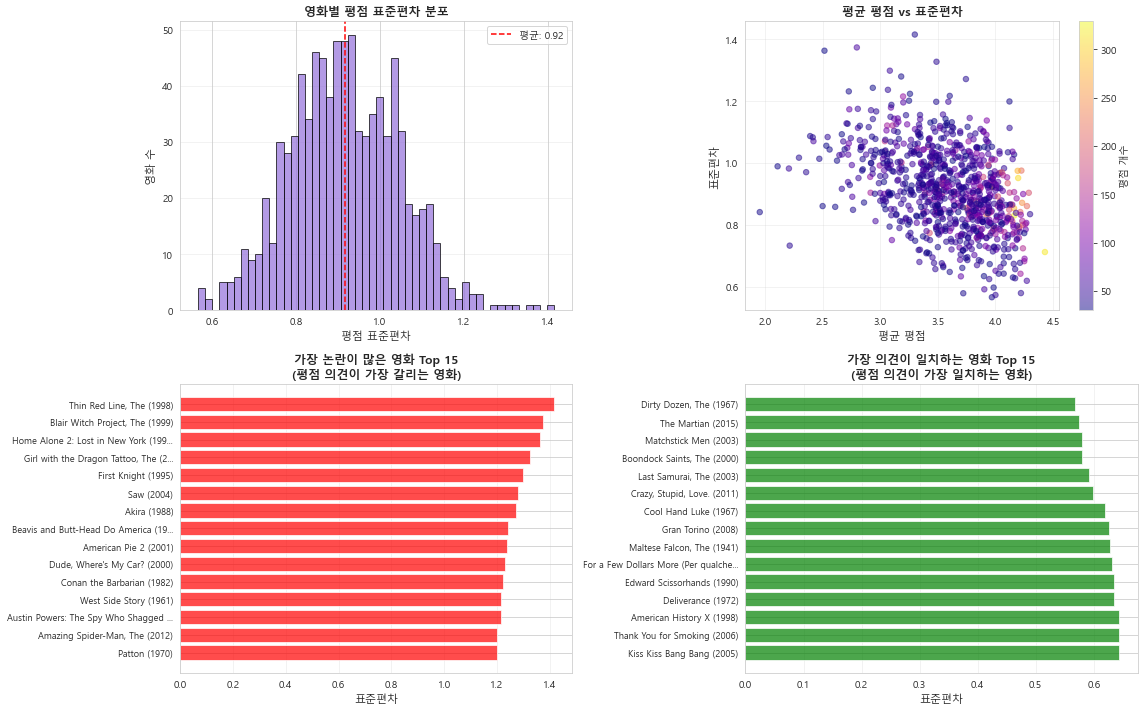


📊 가장 논란이 많은 영화 Top 10:


,title,mean_rating,std_rating,rating_count
431,"Thin Red Line, The (1998)",3.300000,1.415253,35
460,"Blair Witch Project, The (1999)",2.796875,1.373556,64
486,Home Alone 2: Lost in New York (1992),2.516129,1.363108,31
850,"Girl with the Dragon Tattoo, The (2011)",3.488095,1.327422,42
46,First Knight (1995),3.083333,1.298584,54
712,Saw (2004),3.181818,1.279759,33
274,Akira (1988),3.743590,1.271509,39
306,Beavis and Butt-Head Do America (1996),2.935484,1.243261,31
602,American Pie 2 (2001),3.066667,1.236748,45
570,"Dude, Where's My Car? (2000)",2.727273,1.231684,33



📊 가장 의견이 일치하는 영화 Top 10:


,title,mean_rating,std_rating,rating_count
481,"Dirty Dozen, The (1967)",3.968750,0.567074,32
878,The Martian (2015),4.000000,0.574271,48
668,Matchstick Men (2003),3.720588,0.579853,34
514,"Boondock Saints, The (2000)",4.220930,0.580459,43
681,"Last Samurai, The (2003)",3.903226,0.592568,62
845,"Crazy, Stupid, Love. (2011)",3.983871,0.598385,31
276,Cool Hand Luke (1967),4.271930,0.620125,57
807,Gran Torino (2008),3.945652,0.625640,46
192,"Maltese Falcon, The (1941)",4.170455,0.628242,44
542,For a Few Dollars More (Per qualche dollaro in...,4.151515,0.631032,33



💡 인사이트:
- 표준편차가 가장 큰 영화: Thin Red Line, The (1998)
  평균: 3.30, 표준편차: 1.415
- 표준편차가 가장 작은 영화: Dirty Dozen, The (1967)
  평균: 3.97, 표준편차: 0.567


In [65]:
# 영화별 평점 표준편차 및 분산 계산
movie_variance = ratings.groupby('movieId').agg({
    'rating': ['mean', 'std', 'var', 'count']
}).reset_index()
movie_variance.columns = ['movieId', 'mean_rating', 'std_rating', 'var_rating', 'rating_count']

# 평점이 충분한 영화만 선택 (최소 30개)
movie_variance_filtered = movie_variance[movie_variance['rating_count'] >= 30].copy()
movie_variance_filtered = movie_variance_filtered.merge(movies[['movieId', 'title', 'genres']], on='movieId')

print(f"📊 평점이 30개 이상인 영화: {len(movie_variance_filtered):,}개")
print(f"평균 표준편차: {movie_variance_filtered['std_rating'].mean():.3f}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 표준편차 분포
axes[0, 0].hist(movie_variance_filtered['std_rating'], bins=50, 
                color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('평점 표준편차', fontsize=11)
axes[0, 0].set_ylabel('영화 수', fontsize=11)
axes[0, 0].set_title('영화별 평점 표준편차 분포', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=movie_variance_filtered['std_rating'].mean(), 
                    color='red', linestyle='--', label=f'평균: {movie_variance_filtered["std_rating"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 평균 평점 vs 표준편차
scatter = axes[0, 1].scatter(movie_variance_filtered['mean_rating'], 
                             movie_variance_filtered['std_rating'],
                             c=movie_variance_filtered['rating_count'], 
                             cmap='plasma', alpha=0.5, s=30)
axes[0, 1].set_xlabel('평균 평점', fontsize=11)
axes[0, 1].set_ylabel('표준편차', fontsize=11)
axes[0, 1].set_title('평균 평점 vs 표준편차', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 1], label='평점 개수')

# 3. 가장 논란이 많은 영화 (표준편차 큰 영화) Top 15
most_controversial = movie_variance_filtered.nlargest(15, 'std_rating')
axes[1, 0].barh(range(len(most_controversial)), most_controversial['std_rating'].values,
                color='red', alpha=0.7)
axes[1, 0].set_yticks(range(len(most_controversial)))
axes[1, 0].set_yticklabels([title[:35] + '...' if len(title) > 35 else title 
                             for title in most_controversial['title'].values], fontsize=9)
axes[1, 0].set_xlabel('표준편차', fontsize=11)
axes[1, 0].set_title('가장 논란이 많은 영화 Top 15\n(평점 의견이 가장 갈리는 영화)', 
                      fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. 가장 의견이 일치하는 영화 (표준편차 작은 영화) Top 15
most_agreed = movie_variance_filtered.nsmallest(15, 'std_rating')
axes[1, 1].barh(range(len(most_agreed)), most_agreed['std_rating'].values,
                color='green', alpha=0.7)
axes[1, 1].set_yticks(range(len(most_agreed)))
axes[1, 1].set_yticklabels([title[:35] + '...' if len(title) > 35 else title 
                             for title in most_agreed['title'].values], fontsize=9)
axes[1, 1].set_xlabel('표준편차', fontsize=11)
axes[1, 1].set_title('가장 의견이 일치하는 영화 Top 15\n(평점 의견이 가장 일치하는 영화)', 
                      fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 상세 정보 출력
print("\n📊 가장 논란이 많은 영화 Top 10:")
display(most_controversial[['title', 'mean_rating', 'std_rating', 'rating_count']].head(10))

print("\n📊 가장 의견이 일치하는 영화 Top 10:")
display(most_agreed[['title', 'mean_rating', 'std_rating', 'rating_count']].head(10))

print("\n💡 인사이트:")
print(f"- 표준편차가 가장 큰 영화: {most_controversial.iloc[0]['title']}")
print(f"  평균: {most_controversial.iloc[0]['mean_rating']:.2f}, 표준편차: {most_controversial.iloc[0]['std_rating']:.3f}")
print(f"- 표준편차가 가장 작은 영화: {most_agreed.iloc[0]['title']}")
print(f"  평균: {most_agreed.iloc[0]['mean_rating']:.2f}, 표준편차: {most_agreed.iloc[0]['std_rating']:.3f}")


## 15. 사용자 평점 패턴 분석 (관대한 vs 까다로운 사용자)


📊 평점 20개 이상 남긴 사용자: 610명

사용자 유형 분포:
user_type
보통 사용자      447
관대한 사용자     153
까다로운 사용자     10
Name: count, dtype: int64


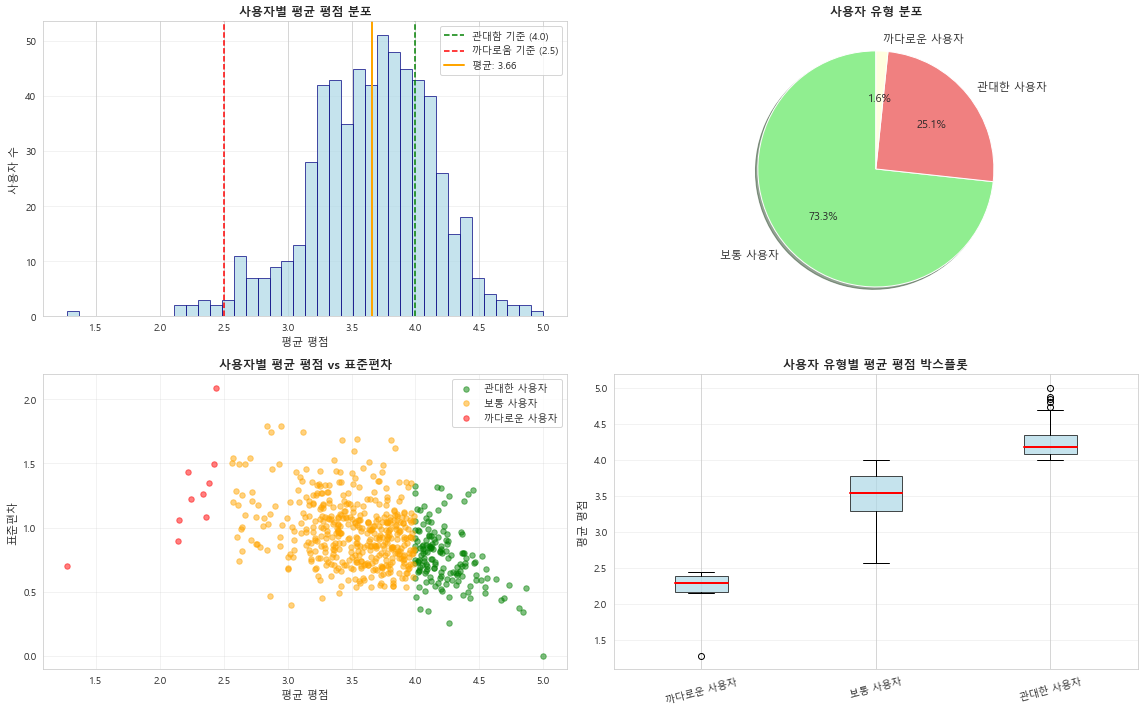


📊 사용자 유형별 상세 통계:

관대한 사용자:
  - 수: 153명
  - 평균 평점: 4.223 (±0.768)
  - 평균 평가 영화 수: 92.5개

보통 사용자:
  - 수: 447명
  - 평균 평점: 3.496 (±0.974)
  - 평균 평가 영화 수: 188.7개

까다로운 사용자:
  - 수: 10명
  - 평균 평점: 2.198 (±1.258)
  - 평균 평가 영화 수: 232.3개

📊 가장 관대한 사용자 Top 5:


,userId,mean_rating,std_rating,rating_count
52,53,5.000000,0.000000,20
250,251,4.869565,0.526942,23
514,515,4.846154,0.339683,26
24,25,4.807692,0.376216,26
29,30,4.735294,0.553711,34



📊 가장 까다로운 사용자 Top 5:


,userId,mean_rating,std_rating,rating_count
441,442,1.275000,0.697269,20
138,139,2.144330,0.894597,194
507,508,2.145833,1.057881,24
152,153,2.217877,1.431984,179
566,567,2.245455,1.221076,385



💡 Item-based CF에서의 의미:
- 사용자마다 평점 부여 기준이 다름 (평점 정규화 필요성)
- 관대한 사용자의 낮은 평점은 까다로운 사용자의 낮은 평점과 다른 의미
- User-mean centering 또는 Z-score 정규화 고려 필요


In [66]:
# 사용자별 평점 패턴 분석
user_patterns = ratings.groupby('userId').agg({
    'rating': ['mean', 'std', 'count', 'min', 'max']
}).reset_index()
user_patterns.columns = ['userId', 'mean_rating', 'std_rating', 'rating_count', 'min_rating', 'max_rating']

# 평점을 충분히 남긴 사용자만 선택 (20개 이상)
user_patterns_filtered = user_patterns[user_patterns['rating_count'] >= 20].copy()

# 사용자 유형 분류
def classify_user(row):
    if row['mean_rating'] >= 4.0:
        return '관대한 사용자'
    elif row['mean_rating'] <= 2.5:
        return '까다로운 사용자'
    else:
        return '보통 사용자'

user_patterns_filtered['user_type'] = user_patterns_filtered.apply(classify_user, axis=1)

print(f"📊 평점 20개 이상 남긴 사용자: {len(user_patterns_filtered):,}명")
print(f"\n사용자 유형 분포:")
print(user_patterns_filtered['user_type'].value_counts())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 사용자별 평균 평점 분포
axes[0, 0].hist(user_patterns_filtered['mean_rating'], bins=40, 
                color='lightblue', edgecolor='navy', alpha=0.7)
axes[0, 0].set_xlabel('평균 평점', fontsize=11)
axes[0, 0].set_ylabel('사용자 수', fontsize=11)
axes[0, 0].set_title('사용자별 평균 평점 분포', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=4.0, color='green', linestyle='--', label='관대함 기준 (4.0)')
axes[0, 0].axvline(x=2.5, color='red', linestyle='--', label='까다로움 기준 (2.5)')
axes[0, 0].axvline(x=user_patterns_filtered['mean_rating'].mean(), 
                    color='orange', linestyle='-', linewidth=2, 
                    label=f'평균: {user_patterns_filtered["mean_rating"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 사용자 유형별 분포 (파이 차트)
user_type_counts = user_patterns_filtered['user_type'].value_counts()
colors_pie = ['lightgreen', 'lightcoral', 'lightyellow']
axes[0, 1].pie(user_type_counts.values, labels=user_type_counts.index, 
               autopct='%1.1f%%', colors=colors_pie, startangle=90, 
               shadow=True, textprops={'fontsize': 11})
axes[0, 1].set_title('사용자 유형 분포', fontsize=12, fontweight='bold')

# 3. 평균 평점 vs 표준편차
colors_scatter = {'관대한 사용자': 'green', '보통 사용자': 'orange', '까다로운 사용자': 'red'}
for user_type in user_patterns_filtered['user_type'].unique():
    data = user_patterns_filtered[user_patterns_filtered['user_type'] == user_type]
    axes[1, 0].scatter(data['mean_rating'], data['std_rating'], 
                       alpha=0.5, s=30, c=colors_scatter[user_type], 
                       label=user_type)
axes[1, 0].set_xlabel('평균 평점', fontsize=11)
axes[1, 0].set_ylabel('표준편차', fontsize=11)
axes[1, 0].set_title('사용자별 평균 평점 vs 표준편차', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. 사용자 유형별 평점 분포 박스플롯
user_type_order = ['까다로운 사용자', '보통 사용자', '관대한 사용자']
user_type_data = [user_patterns_filtered[user_patterns_filtered['user_type'] == ut]['mean_rating'].values 
                  for ut in user_type_order]
bp = axes[1, 1].boxplot(user_type_data, labels=user_type_order, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('평균 평점', fontsize=11)
axes[1, 1].set_title('사용자 유형별 평균 평점 박스플롯', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 상세 통계
print("\n📊 사용자 유형별 상세 통계:")
for user_type in ['관대한 사용자', '보통 사용자', '까다로운 사용자']:
    data = user_patterns_filtered[user_patterns_filtered['user_type'] == user_type]
    print(f"\n{user_type}:")
    print(f"  - 수: {len(data):,}명")
    print(f"  - 평균 평점: {data['mean_rating'].mean():.3f} (±{data['std_rating'].mean():.3f})")
    print(f"  - 평균 평가 영화 수: {data['rating_count'].mean():.1f}개")

# 극단적인 사용자 찾기
print("\n📊 가장 관대한 사용자 Top 5:")
most_generous = user_patterns_filtered.nlargest(5, 'mean_rating')
display(most_generous[['userId', 'mean_rating', 'std_rating', 'rating_count']])

print("\n📊 가장 까다로운 사용자 Top 5:")
most_critical = user_patterns_filtered.nsmallest(5, 'mean_rating')
display(most_critical[['userId', 'mean_rating', 'std_rating', 'rating_count']])

print("\n💡 Item-based CF에서의 의미:")
print("- 사용자마다 평점 부여 기준이 다름 (평점 정규화 필요성)")
print("- 관대한 사용자의 낮은 평점은 까다로운 사용자의 낮은 평점과 다른 의미")
print("- User-mean centering 또는 Z-score 정규화 고려 필요")


## 16. 영화 간 공동 평가 분석 (Co-rating Pattern)


️< 공동 평가 매트릭스 (Co-rating Matrix) >
대각선: 그 영화를 평가한 총 사용자 수 (최대값)
비대각선: 두 영화를 모두 평가한 사용자 수

왜 이게 중요한가?
    공동 평가가 많을수록:
    ✅ 두 영화의 유사도를 신뢰성 있게 계산 가능
    ✅ 추천 결과가 더 정확함
    ✅ 알고리즘이 안정적으로 작동
    공동 평가가 적으면:
    ⚠️ 유사도 계산이 불안정
    ⚠️ 추천이 부정확할 수 있음
    ⚠️ Cold start 문제 발생

공동 평가가 많은 경우 (150명):
    150명이 두 영화 모두 평가→ 패턴이 명확함→ 신뢰할 수 있는 유사도→ 정확한 추천 가능! ✅
공동 평가가 적은 경우 (5명):
    단 5명만 두 영화 모두 평가→ 샘플이 너무 적음→ 우연의 일치일 수 있음→ 추천이 부정확할 수 있음 ⚠️

이 분석 결과로 알 수 있는 것은?
    ✅ 인기 영화들끼리는 공동 평가가 많음
    ✅ 유사도 계산이 안정적
    ⚠️ 비인기 영화는 공동 평가가 적을 것 → 문제!

색이 진한 칸 (많은 공동 평가):
    두 영화가 비슷한 시기에 인기
    비슷한 장르/테마
    유사도 계산 신뢰성 높음
색이 옅은 칸 (적은 공동 평가):
    서로 다른 시기의 영화
    다른 관객층
    유사도 계산 조심해야 함    

⏳ 공동 평가 매트릭스 계산 중... (시간이 걸릴 수 있습니다)
✅ 계산 완료!


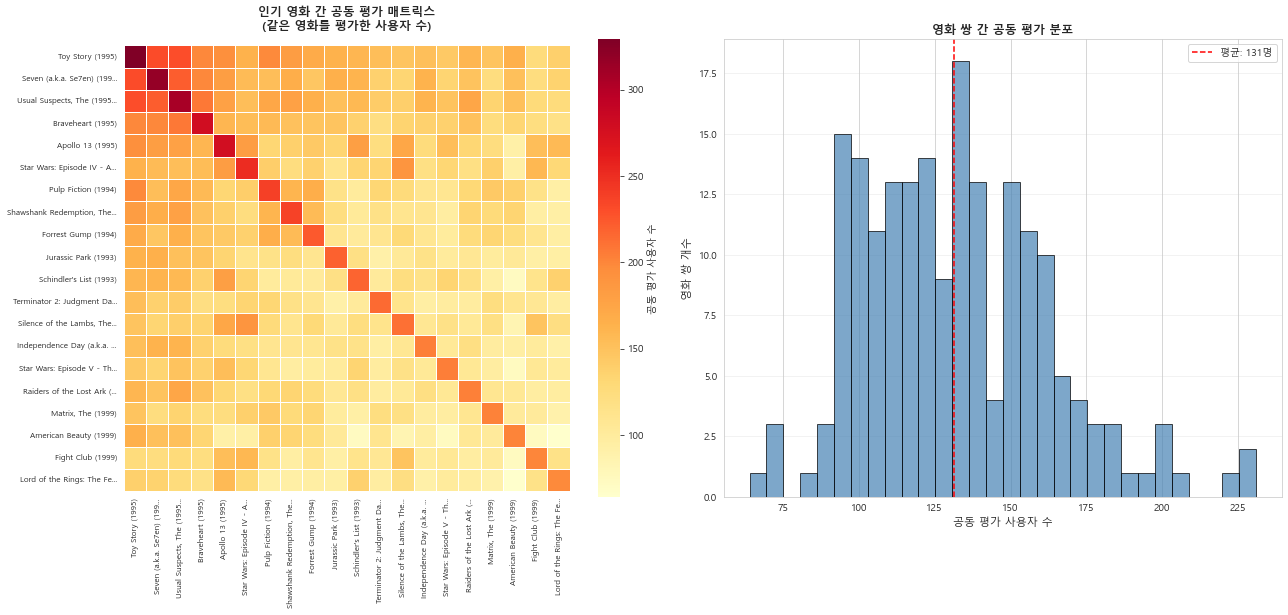


📊 공동 평가 통계 (상위 20개 인기 영화 기준):
평균 공동 평가 사용자 수: 131명
최소 공동 평가 사용자 수: 64명
최대 공동 평가 사용자 수: 231명
중앙값: 128명


In [67]:
# 영화 간 공동 평가 패턴 분석 (Item-based CF의 핵심)
# 가장 많이 평가된 영화 20개를 선택하여 분석

top_movies_for_corating = movie_stats.nlargest(20, 'rating_count')['movieId'].values
top_movies_names = dict(zip(top_movies_for_corating, 
                            movie_stats[movie_stats['movieId'].isin(top_movies_for_corating)]['title']))

# 각 영화 쌍에 대해 공동으로 평가한 사용자 수 계산
print("⏳ 공동 평가 매트릭스 계산 중... (시간이 걸릴 수 있습니다)")

corating_matrix = pd.DataFrame(0, index=top_movies_for_corating, columns=top_movies_for_corating)

for movie1 in top_movies_for_corating:
    users1 = set(ratings[ratings['movieId'] == movie1]['userId'])
    for movie2 in top_movies_for_corating:
        if movie1 <= movie2:  # 대칭 행렬이므로 절반만 계산
            users2 = set(ratings[ratings['movieId'] == movie2]['userId'])
            common_users = len(users1.intersection(users2))
            corating_matrix.loc[movie1, movie2] = common_users
            corating_matrix.loc[movie2, movie1] = common_users

print("✅ 계산 완료!")

# 시각화를 위해 영화 제목으로 변경
corating_matrix.index = [top_movies_names[mid][:25] + '...' if len(top_movies_names[mid]) > 25 
                         else top_movies_names[mid] for mid in corating_matrix.index]
corating_matrix.columns = [top_movies_names[mid][:25] + '...' if len(top_movies_names[mid]) > 25 
                           else top_movies_names[mid] for mid in corating_matrix.columns]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. 공동 평가 히트맵
sns.heatmap(corating_matrix, cmap='YlOrRd', annot=False, fmt='d', 
            linewidths=0.5, cbar_kws={'label': '공동 평가 사용자 수'},
            ax=axes[0], square=True)
axes[0].set_title('인기 영화 간 공동 평가 매트릭스\n(같은 영화를 평가한 사용자 수)', 
                  fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# 2. 공동 평가 분포 (대각선 제외)
corating_values = []
for i in range(len(corating_matrix)):
    for j in range(i+1, len(corating_matrix)):
        corating_values.append(corating_matrix.iloc[i, j])

axes[1].hist(corating_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('공동 평가 사용자 수', fontsize=11)
axes[1].set_ylabel('영화 쌍 개수', fontsize=11)
axes[1].set_title('영화 쌍 간 공동 평가 분포', fontsize=12, fontweight='bold')
axes[1].axvline(x=np.mean(corating_values), color='red', linestyle='--', 
                label=f'평균: {np.mean(corating_values):.0f}명')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 통계 정보
print(f"\n📊 공동 평가 통계 (상위 20개 인기 영화 기준):")
print(f"평균 공동 평가 사용자 수: {np.mean(corating_values):.0f}명")
print(f"최소 공동 평가 사용자 수: {np.min(corating_values):.0f}명")
print(f"최대 공동 평가 사용자 수: {np.max(corating_values):.0f}명")
print(f"중앙값: {np.median(corating_values):.0f}명")

# 특정 영화 쌍의 공동 평가 찾기
max_idx = np.unravel_index(np.argmax(corating_matrix.values), corating_matrix.shape)
if max_idx[0] != max_idx[1]:
    print(f"\n가장 많이 함께 평가된 영화 쌍:")
    print(f"  '{corating_matrix.index[max_idx[0]]}' & '{corating_matrix.columns[max_idx[1]]}'")
    print(f"  공동 평가 사용자: {corating_matrix.iloc[max_idx[0], max_idx[1]]:.0f}명")


### 공동 평가의 중요성

이 분석은 **Item-based 협업 필터링의 핵심**입니다:
- 두 영화를 모두 평가한 사용자가 많을수록 두 영화 간 유사도 계산이 신뢰성 있음
- 공동 평가 사용자가 적으면 유사도 계산이 불안정함
- 최소 공동 평가 임계값 설정 필요 (예: 최소 5명 이상)


---

## 📋 최종 EDA 요약 및 다음 단계

### 🎉 완료된 분석: 총 **16개 섹션**

이 노트북에서 MovieLens 데이터를 다각도로 분석했습니다:

**📊 데이터 탐색** (1-6): 기본 정보, 장르, 평점, 사용자, 인기도, 시간 패턴  
**⭐ 핵심 분석** (7-9): 희소성, User-Item 매트릭스, 태그  
**🎬 심화 분석** (11-16): 리메이크, 연도, 장르별 평점, 논란, 사용자 패턴, 공동 평가  

### 🎯 핵심 발견사항

- **희소성 98%+**: 대부분의 User-Item 조합이 비어있음 → 전처리 필수
- **공동 평가**: 인기 영화끼리만 충분한 공동 평가 존재 → 유사도 계산 시 주의  
- **사용자 편차**: 평점 기준이 사람마다 크게 다름 → 정규화 필수
- **리메이크**: 오리지널과 리메이크의 평점 차이 존재 → 추천에 활용 가능

### 🚀 다음 단계

`04_Item_based_협업필터링.ipynb`에서 실제 추천 시스템을 구현합니다!


In [ ]:
print("=" * 100)
print("🎉 MovieLens 데이터 탐색적 분석(EDA) 완료! - 총 16개 섹션")
print("=" * 100)

print("\n✅ 완료된 분석 항목:")
analyses = [
    "1. 데이터 로드 및 기본 정보 확인",
    "2. 장르 분석 (장르별 영화 분포)",
    "3. 평점 분석 (평점 분포 및 통계)",
    "4. 사용자 활동 분석",
    "5. 영화 인기도 분석",
    "6. 시간대별 분석",
    "7. 데이터 희소성 분석",
    "8. User-Item 매트릭스 시각화",
    "9. 태그 분석",
    "10. EDA 요약 및 인사이트",
    "11. 리메이크 영화 분석 🎬 (오리지널 vs 리메이크 평점 비교)",
    "12. 영화 개봉 연도 분석",
    "13. 장르별 평균 평점 및 인기도 분석",
    "14. 영화별 평점 분산 분석 (논란의 영화)",
    "15. 사용자 평점 패턴 분석 (관대한 vs 까다로운 사용자)",
    "16. 영화 간 공동 평가 분석 (Co-rating Pattern) ⭐"
]

for analysis in analyses:
    print(f"  ✓ {analysis}")

print("\n" + "=" * 90)
print("🚀 Item-based 협업 필터링 구현을 위한 핵심 인사이트")
print("=" * 90)

insights = """
1️⃣ 데이터 전처리 전략:
   - 최소 평점 임계값: 영화 20~50개, 사용자 10~20개 평점
   - 희소성 98%+ → 희소 행렬 자료구조 사용 권장
   
2️⃣ 유사도 계산:
   - 코사인 유사도 또는 조정된 코사인 유사도 추천
   - 최소 공동 평가 사용자 수: 5~10명 이상
   - 평점 정규화: User-mean centering 필수 (사용자마다 평점 기준 상이)
   
3️⃣ 추천 생성:
   - K개의 유사 아이템 선택 (K=10~50)
   - 가중 평균으로 평점 예측
   - 이미 본 영화는 제외
   
4️⃣ 추가 고려사항:
   - 장르 정보 활용 (Content-based와 결합 → Hybrid)
   - 리메이크 정보 활용 (오리지널 본 사람에게 리메이크 추천)
   - 시간 가중치 적용 (최근 평점에 더 높은 가중치)
   - 인기 편향 완화 (인기 영화에만 편중되지 않도록)
   - 논란의 영화(표준편차 큰 영화) 추천 시 주의
   
5️⃣ 평가 방법:
   - Train/Test Split (80/20 또는 시간 기반 분할)
   - RMSE, MAE로 예측 정확도 평가
   - Precision@K, Recall@K, NDCG로 추천 품질 평가
"""

print(insights)

print("\n" + "=" * 100)
print("📁 다음 단계: Item-based 협업 필터링 구현")
print("=" * 100)
print("  → 파일: 04_Item_based_협업필터링.ipynb")
print("  → 내용: 실제 추천 시스템 구현 및 평가")
print("=" * 100)



🎉 포괄적인 데이터 탐색 완료!

✅ 완료된 분석 항목:
  ✓ 1. 데이터 로드 및 기본 정보 확인
  ✓ 2. 장르 분석 (장르별 영화 분포)
  ✓ 3. 평점 분석 (평점 분포 및 통계)
  ✓ 4. 사용자 활동 분석
  ✓ 5. 영화 인기도 분석
  ✓ 6. 시간대별 분석
  ✓ 7. 데이터 희소성 분석
  ✓ 8. User-Item 매트릭스 시각화
  ✓ 9. 태그 분석
  ✓ 10. EDA 요약 및 인사이트
  ✓ 11. 영화 개봉 연도 분석
  ✓ 12. 장르별 평균 평점 및 인기도 분석
  ✓ 13. 영화별 평점 분산 분석 (논란의 영화)
  ✓ 14. 사용자 평점 패턴 분석 (관대한 vs 까다로운 사용자)
  ✓ 15. 영화 간 공동 평가 분석 (Co-rating Pattern)

🚀 Item-based 협업 필터링 구현을 위한 핵심 인사이트

1️⃣ 데이터 전처리 전략:
   - 최소 평점 임계값: 영화 20~50개, 사용자 10~20개 평점
   - 희소성 98%+ → 희소 행렬 자료구조 사용 권장
   
2️⃣ 유사도 계산:
   - 코사인 유사도 또는 조정된 코사인 유사도 추천
   - 최소 공동 평가 사용자 수: 5~10명 이상
   - 평점 정규화: User-mean centering 필수 (사용자마다 평점 기준 상이)
   
3️⃣ 추천 생성:
   - K개의 유사 아이템 선택 (K=10~50)
   - 가중 평균으로 평점 예측
   - 이미 본 영화는 제외
   
4️⃣ 추가 고려사항:
   - 장르 정보 활용 (Content-based와 결합 → Hybrid)
   - 시간 가중치 적용 (최근 평점에 더 높은 가중치)
   - 인기 편향 완화 (인기 영화에만 편중되지 않도록)
   
5️⃣ 평가 방법:
   - Train/Test Split (80/20 또는 시간 기반 분할)
   - RMSE, MAE로 예측 정확도 평가
   - Precision@K, Recall@K, NDCG로 추천 품질 평가

